# EDA completo — Base Raman RRUFF (7 dominios ZIP)

Este notebook realiza un **análisis exploratorio reproducible, visual y orientado a decisiones** de los siete archivos ZIP del proyecto. No entrena ningún modelo ni modifica los datos originales.

## Preguntas que responde

1. ¿Cuántos archivos, minerales y fuentes RRUFF contiene cada dominio?
2. ¿Qué proporción corresponde a datos `RAW` y `Processed`?
3. ¿Qué tan desbalanceadas están las clases y las fuentes?
4. ¿Qué minerales y fuentes aparecen en varios dominios?
5. ¿Existen duplicados exactos, conflictos de etiqueta o IDs de fuente problemáticos?
6. ¿Cómo varían rango, resolución, intensidad y forma espectral entre calidad y orientación?
7. ¿Qué implicaciones tiene todo esto para un split agrupado y para el modelado?

> **Unidad de análisis.** Un archivo TXT es una medición espectral. Una `source_id` es una entrada/fuente RRUFF (por ejemplo, `R040063`). No deben tratarse como observaciones independientes equivalentes.

## Este notebook lee los TXT directamente desde los ZIP y muestra resultados inline. No exporta archivos ni crea carpetas de resultados.

In [1]:
# %pip install pandas numpy scipy matplotlib seaborn scikit-learn tqdm

import io, re, json, hashlib, zipfile, platform, sys, warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (11, 5.5), "figure.dpi": 120})

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__, "| numpy:", np.__version__)
# Modo solo pantalla: no se escriben resultados en disco.
def _mostrar_en_pantalla(obj, destino=None, *args, **kwargs):
    nombre = str(destino) if destino is not None else "salida tabular"
    print(f"\n[SOLO PANTALLA] {nombre} | dimensiones: {getattr(obj, 'shape', None)}")
    try:
        display(obj if len(obj) <= 40 else obj.head(40))
    except Exception:
        print(obj)

pd.DataFrame.to_csv = lambda self, path_or_buf=None, *a, **k: _mostrar_en_pantalla(self, path_or_buf)
pd.Series.to_csv = lambda self, path_or_buf=None, *a, **k: _mostrar_en_pantalla(self, path_or_buf)
np.save = lambda destino, datos, *a, **k: _mostrar_en_pantalla(pd.DataFrame(np.atleast_1d(datos)), destino)
plt.savefig = lambda destino, *a, **k: print(f"[SOLO PANTALLA] Figura mostrada; no se guarda {destino}")
Path.write_text = lambda self, data, *a, **k: print(f"[SOLO PANTALLA] {self.name}:\n{str(data)[:4000]}") or len(str(data))

class ZipMember:
    """Referencia ligera a un TXT dentro de un ZIP, sin extracción a disco."""
    def __init__(self, archive_path, member):
        self.archive_path, self.member = Path(archive_path), member
    @property
    def name(self): return Path(self.member).name
    def read_bytes(self):
        with zipfile.ZipFile(self.archive_path) as zf: return zf.read(self.member)
    def __str__(self): return f"{self.archive_path.name}::{self.member}"
    def __repr__(self): return str(self)

def open_spectrum(member):
    import io
    return io.StringIO(member.read_bytes().decode("utf-8", errors="replace"))


Python: 3.11.15
pandas: 3.0.5 | numpy: 2.4.6


## 1. Configuración y localización de los siete ZIP

El notebook busca los archivos junto al notebook, dentro de `upload/` y en `/content/`. Para Google Drive, añade su carpeta a `SEARCH_DIRS`.

In [2]:
REQUIRED_ZIPS = [
    "excellent_unoriented.zip", "excellent_oriented.zip",
    "fair_unoriented.zip", "fair_oriented.zip",
    "poor_unoriented.zip",
    "unrated_unoriented.zip", "unrated_oriented.zip",
]

SEARCH_DIRS = [Path.cwd(), Path.cwd() / "upload", Path("/content")]
# Ejemplo Google Drive:
# from google.colab import drive; drive.mount('/content/drive')
# SEARCH_DIRS.append(Path('/content/drive/MyDrive/RRUFF'))

OUTPUT_DIR = Path("RRUFF_7_ZIPS_EDA_RESULTS")

RANDOM_SEED = 42
TOP_N_CLASSES = 30
PCA_SAMPLE_SIZE = 5000
PLOT_SAMPLE_PER_DOMAIN = 6
N_GRID_POINTS = 512

def resolve_archives():
    found = {}
    for name in REQUIRED_ZIPS:
        matches = [(d / name).resolve() for d in SEARCH_DIRS if (d / name).is_file()]
        if matches:
            found[name] = matches[0]
    missing = sorted(set(REQUIRED_ZIPS) - set(found))
    if missing:
        raise FileNotFoundError("Faltan los ZIP requeridos: " + ", ".join(missing))
    return found

archives = resolve_archives()
archive_table = pd.DataFrame([
    {"domain": Path(name).stem, "zip_filename": name, "path": str(path),
     "quality": Path(name).stem.split("_")[0],
     "orientation": "unoriented" if "unoriented" in name else "oriented",
     "size_mb": path.stat().st_size / 2**20}
    for name, path in archives.items()
])
display(archive_table)
archive_table.to_csv(OUTPUT_DIR / "archive_inventory.csv", index=False)


,domain,zip_filename,path,quality,orientation,size_mb
0,excellent_unoriented,excellent_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/exce...,excellent,unoriented,229.403743
1,excellent_oriented,excellent_oriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/exce...,excellent,oriented,77.124936
2,fair_unoriented,fair_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/fair...,fair,unoriented,58.683879
3,fair_oriented,fair_oriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/fair...,fair,oriented,0.264505
4,poor_unoriented,poor_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/poor...,poor,unoriented,33.195755
5,unrated_unoriented,unrated_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/unra...,unrated,unoriented,12.312113
6,unrated_oriented,unrated_oriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/unra...,unrated,oriented,39.437395



[SOLO PANTALLA] RRUFF_7_ZIPS_EDA_RESULTS/archive_inventory.csv | dimensiones: (7, 6)


,domain,zip_filename,path,quality,orientation,size_mb
0,excellent_unoriented,excellent_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/exce...,excellent,unoriented,229.403743
1,excellent_oriented,excellent_oriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/exce...,excellent,oriented,77.124936
2,fair_unoriented,fair_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/fair...,fair,unoriented,58.683879
3,fair_oriented,fair_oriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/fair...,fair,oriented,0.264505
4,poor_unoriented,poor_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/poor...,poor,unoriented,33.195755
5,unrated_unoriented,unrated_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/unra...,unrated,unoriented,12.312113
6,unrated_oriented,unrated_oriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/unra...,unrated,oriented,39.437395


## 2. Inventario interno e integridad

Se inspeccionan los ZIP sin extraerlos. Esto reduce el uso de disco y permite detectar miembros corruptos, extensiones inesperadas y tamaños anómalos.

,domain,all_members,txt_files,uncompressed_mb,compressed_mb,compression_ratio
0,excellent_unoriented,11415,11415,535.3,226.1,2.37
1,excellent_oriented,7668,7668,174.8,74.8,2.34
6,unrated_oriented,3778,3778,89.5,38.2,2.34
2,fair_unoriented,2951,2951,136.8,57.8,2.37
4,poor_unoriented,1639,1639,76.9,32.7,2.35
5,unrated_unoriented,639,639,32.6,12.1,2.69
3,fair_oriented,25,25,0.6,0.3,2.35



[SOLO PANTALLA] RRUFF_7_ZIPS_EDA_RESULTS/zip_inventory.csv | dimensiones: (7, 6)


,domain,all_members,txt_files,uncompressed_mb,compressed_mb,compression_ratio
0,excellent_unoriented,11415,11415,535.277731,226.082316,2.367623
1,excellent_oriented,7668,7668,174.788283,74.766196,2.337798
6,unrated_oriented,3778,3778,89.530623,38.233944,2.341653
2,fair_unoriented,2951,2951,136.798874,57.823344,2.365807
4,poor_unoriented,1639,1639,76.938472,32.718557,2.351524
5,unrated_unoriented,639,639,32.561789,12.127148,2.685033
3,fair_oriented,25,25,0.603695,0.256760,2.351206


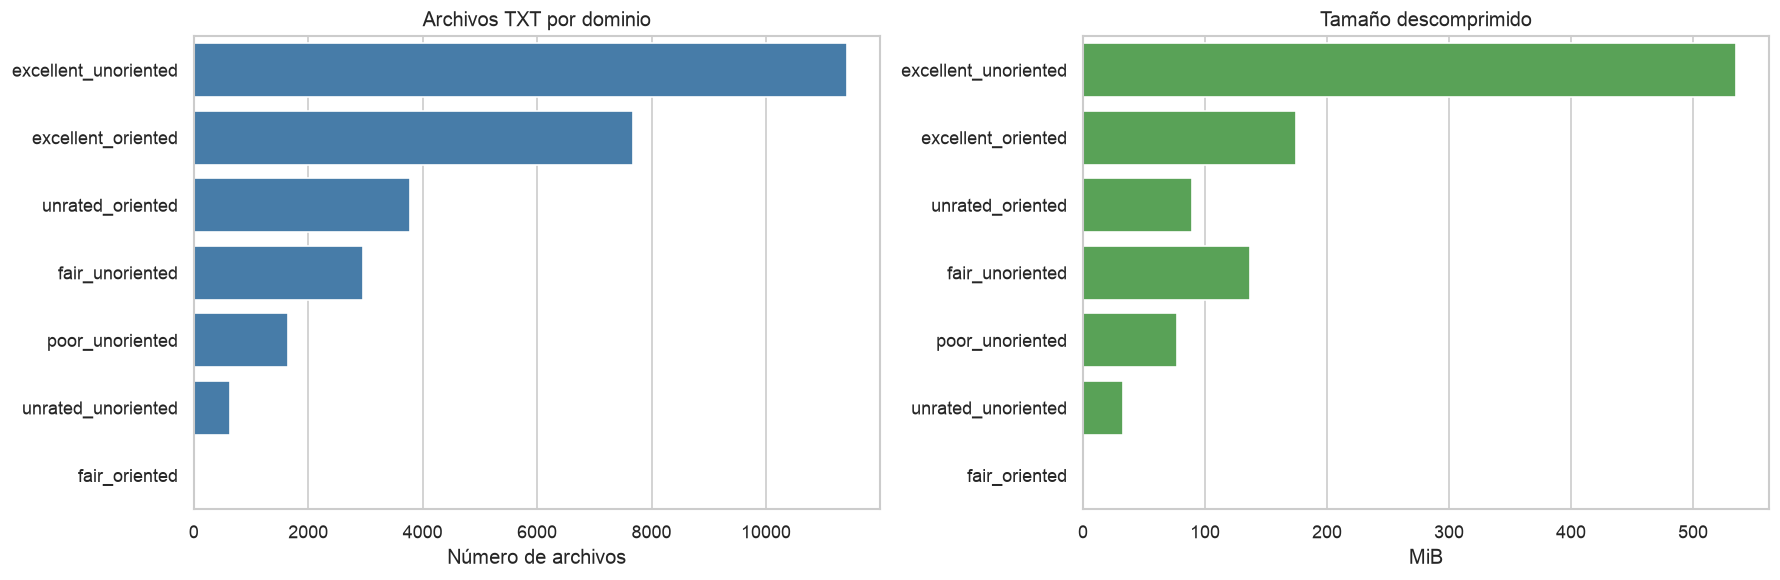

In [3]:
inventory_rows = []
for name, path in archives.items():
    domain = Path(name).stem
    with zipfile.ZipFile(path) as zf:
        bad = zf.testzip()
        if bad:
            raise RuntimeError(f"Miembro corrupto en {name}: {bad}")
        members = [m for m in zf.infolist() if not m.is_dir()]
        txt = [m for m in members if m.filename.lower().endswith(".txt")]
        inventory_rows.append({
            "domain": domain, "all_members": len(members), "txt_files": len(txt),
            "uncompressed_mb": sum(m.file_size for m in members) / 2**20,
            "compressed_mb": sum(m.compress_size for m in members) / 2**20,
            "compression_ratio": sum(m.file_size for m in members) / max(sum(m.compress_size for m in members), 1),
        })

zip_inventory = pd.DataFrame(inventory_rows).sort_values("txt_files", ascending=False)
display(zip_inventory.style.format({"uncompressed_mb":"{:.1f}", "compressed_mb":"{:.1f}", "compression_ratio":"{:.2f}"}))
zip_inventory.to_csv(OUTPUT_DIR / "zip_inventory.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=zip_inventory, y="domain", x="txt_files", ax=axes[0], color="#377eb8")
axes[0].set(title="Archivos TXT por dominio", xlabel="Número de archivos", ylabel="")
sns.barplot(data=zip_inventory, y="domain", x="uncompressed_mb", ax=axes[1], color="#4daf4a")
axes[1].set(title="Tamaño descomprimido", xlabel="MiB", ylabel="")
plt.tight_layout(); plt.show()


## 3. Parser auditado y construcción del manifiesto

El nombre aporta mineral, fuente RRUFF, láser, orientación y tipo de dato. El contenido aporta pares `(Raman shift, intensidad)` y encabezados. El `source_id` solo se acepta cuando no existe conflicto entre nombre y encabezado.

Además se calcula SHA-256 sobre los bytes para identificar duplicados exactos entre dominios.

In [4]:
NUMBER = re.compile(r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[Ee][-+]?\d+)?")
RRUFF_ID = re.compile(r"(?<![A-Za-z0-9])R\d{6,8}(?!\d)", re.IGNORECASE)

def unique_rruff_ids(text):
    return sorted({x.upper() for x in RRUFF_ID.findall(text)})

def parse_filename(filename):
    base = Path(filename).name
    parts = base.split("__")
    label = parts[0].replace("_", " ").strip() if parts else "UNKNOWN"
    laser = next((p for p in parts if re.fullmatch(r"\d{3,4}", p.strip())), None)
    low = base.lower()
    kind = "processed" if "raman_data_processed" in low else ("raw" if "raman_data_raw" in low else "unknown")
    polarization = "depolarized" if "depolarized" in low else ("polarized" if "polarized" in low else "unspecified")
    angle_match = re.search(r"__(\d{1,3})-\d{3}(?:__|$)", base)
    angle = float(angle_match.group(1)) if angle_match else np.nan
    return label, laser, kind, polarization, angle

def parse_spectrum_bytes(raw):
    text = raw.decode("utf-8", errors="replace")
    pairs, headers = [], []
    for line in text.splitlines():
        if line.lstrip().startswith("##"):
            headers.append(line.strip()); continue
        vals = NUMBER.findall(line)
        if len(vals) >= 2:
            try: pairs.append((float(vals[0]), float(vals[1])))
            except ValueError: pass
    if len(pairs) < 10:
        return None, headers, "fewer than 10 numeric pairs"
    arr = np.asarray(pairs, dtype=np.float64)
    arr = arr[np.isfinite(arr[:, 0])]
    if len(arr) < 10: return None, headers, "too few finite Raman coordinates"
    if not np.isfinite(arr[:, 1]).all(): return None, headers, "non-finite intensities"
    order = np.argsort(arr[:, 0]); x, y = arr[order, 0], arr[order, 1]
    ux, inv = np.unique(x, return_inverse=True)
    if len(ux) != len(x):
        sums = np.bincount(inv, weights=y); counts = np.bincount(inv); x, y = ux, sums / counts
    if len(x) < 10 or x[-1] <= x[0]: return None, headers, "degenerate Raman axis"
    if np.max(np.abs(y)) <= 1e-12: return None, headers, "flat or zero spectrum"
    return (x, y), headers, None

rows, plot_reservoir, domain_seen = [], defaultdict(list), defaultdict(int)
rng = np.random.default_rng(RANDOM_SEED)
counter = 0
for zip_name, zip_path in archives.items():
    domain = Path(zip_name).stem
    quality = domain.split("_")[0]
    orientation = "unoriented" if "unoriented" in domain else "oriented"
    with zipfile.ZipFile(zip_path) as zf:
        members = [m for m in zf.infolist() if not m.is_dir() and m.filename.lower().endswith(".txt")]
        for member in tqdm(members, desc=domain):
            raw = zf.read(member)
            result, headers, reason = parse_spectrum_bytes(raw)
            label, laser, kind, polarization, angle = parse_filename(member.filename)
            fids = unique_rruff_ids(Path(member.filename).name)
            hids = unique_rruff_ids("\n".join(headers))
            candidates = sorted(set(fids) | set(hids))
            conflict = bool(fids and hids and set(fids) != set(hids))
            source_id = candidates[0] if len(candidates) == 1 and not conflict else None
            status = ("filename_header_conflict" if conflict else "missing" if not candidates else
                      "multiple_candidates" if len(candidates) > 1 else "filename_header_agree" if fids and hids else
                      "filename_only" if fids else "header_only")
            row = dict(spectrum_id=f"S{counter:07d}", domain=domain, quality=quality,
                       orientation=orientation, member=member.filename, filename=Path(member.filename).name,
                       label=label, source_id=source_id, source_id_status=status,
                       source_id_filename="|".join(fids), source_id_header="|".join(hids),
                       laser_nm=float(laser) if laser else np.nan, data_kind=kind,
                       polarization=polarization, angle_deg=angle, accepted_parse=result is not None,
                       rejection_reason=reason, sha256=hashlib.sha256(raw).hexdigest(), bytes=len(raw))
            if result is not None:
                x, y = result
                dx = np.diff(x)
                row.update(n_points=len(x), min_shift=x.min(), max_shift=x.max(), span_shift=x.max()-x.min(),
                           median_step=np.median(dx), min_intensity=y.min(), max_intensity=y.max(),
                           intensity_range=np.ptp(y), negative_fraction=np.mean(y < 0))
                bucket = plot_reservoir[domain]
                domain_seen[domain] += 1
                if len(bucket) < PLOT_SAMPLE_PER_DOMAIN:
                    bucket.append((counter, x.astype(np.float32), y.astype(np.float32), label, kind))
                else:
                    j = rng.integers(0, domain_seen[domain])
                    if j < PLOT_SAMPLE_PER_DOMAIN: bucket[int(j)] = (counter, x.astype(np.float32), y.astype(np.float32), label, kind)
            rows.append(row); counter += 1

manifest = pd.DataFrame(rows)
manifest.to_csv(OUTPUT_DIR / "spectral_manifest.csv", index=False)
print(f"Archivos auditados: {len(manifest):,}")
display(manifest.head())


excellent_unoriented:   0%|          | 0/11415 [00:00<?, ?it/s]

excellent_oriented:   0%|          | 0/7668 [00:00<?, ?it/s]

fair_unoriented:   0%|          | 0/2951 [00:00<?, ?it/s]

fair_oriented:   0%|          | 0/25 [00:00<?, ?it/s]

poor_unoriented:   0%|          | 0/1639 [00:00<?, ?it/s]

...

unrated_oriented:   0%|          | 0/3778 [00:00<?, ?it/s]


[SOLO PANTALLA] RRUFF_7_ZIPS_EDA_RESULTS/spectral_manifest.csv | dimensiones: (28115, 28)


,spectrum_id,domain,quality,orientation,member,filename,label,source_id,source_id_status,source_id_filename,source_id_header,laser_nm,data_kind,polarization,angle_deg,accepted_parse,rejection_reason,sha256,bytes,n_points,min_shift,max_shift,span_shift,median_step,min_intensity,max_intensity,intensity_range,negative_fraction
0,S0000000,excellent_unoriented,excellent,unoriented,Abelsonite__R070007__Raman__532______Raman_Dat...,Abelsonite__R070007__Raman__532______Raman_Dat...,Abelsonite,R070007,filename_header_agree,R070007,R070007,532.0,processed,unspecified,NaN,True,None,5d2944bff2a639fe46e579371ffda6ebfe4d9b7a77a63f...,47098,2312,153.55700,1267.727,1114.17000,0.4821,0.00000,13142.26000,13142.26000,0.000000
1,S0000001,excellent_unoriented,excellent,unoriented,Abelsonite__R070007__Raman__532______Raman_Dat...,Abelsonite__R070007__Raman__532______Raman_Dat...,Abelsonite,R070007,filename_header_agree,R070007,R070007,532.0,raw,unspecified,NaN,True,None,0d52483b54df773c915efbbba32222c39fb54e22a77d4f...,48411,2379,153.55700,1300.029,1146.47200,0.4821,5903.08300,44656.08000,38752.99700,0.000000
2,S0000002,excellent_unoriented,excellent,unoriented,Abhurite__R060227__Raman__532______Raman_Data_...,Abhurite__R060227__Raman__532______Raman_Data_...,Abhurite,R060227,filename_header_agree,R060227,R060227,532.0,processed,unspecified,NaN,True,None,f455837619a07a213b8a814e26a5307211e02e15879c1e...,48481,2367,163.43140,1304.119,1140.68760,0.4821,0.00000,6294.97300,6294.97300,0.000000
3,S0000003,excellent_unoriented,excellent,unoriented,Abhurite__R060227__Raman__532______Raman_Data_...,Abhurite__R060227__Raman__532______Raman_Data_...,Abhurite,R060227,filename_header_agree,R060227,R060227,532.0,raw,unspecified,NaN,True,None,50899dbe24a5fc813dbc7d26d691000c86cf9c5444599a...,51074,2515,92.07813,1304.119,1212.04087,0.4821,42.78957,8403.48400,8360.69443,0.000000
4,S0000004,excellent_unoriented,excellent,unoriented,Abhurite__R060227__Raman__780______Raman_Data_...,Abhurite__R060227__Raman__780______Raman_Data_...,Abhurite,R060227,filename_header_agree,R060227,R060227,780.0,processed,unspecified,NaN,True,None,7d90f6439e1d6d9d7793251090b323f277b558f1ff1751...,51125,2476,91.82715,1285.066,1193.23885,0.4821,0.00000,6871.24700,6871.24700,0.000000
5,S0000005,excellent_unoriented,excellent,unoriented,Abhurite__R060227__Raman__780______Raman_Data_...,Abhurite__R060227__Raman__780______Raman_Data_...,Abhurite,R060227,filename_header_agree,R060227,R060227,780.0,raw,unspecified,NaN,True,None,f28782ac7519c76156c8785d0f3c33537e4ade582e4433...,50294,2476,91.82715,1285.066,1193.23885,0.4821,51.38430,9798.68800,9747.30370,0.000000
6,S0000006,excellent_unoriented,excellent,unoriented,Actinolite__R040063__Raman__514______Raman_Dat...,Actinolite__R040063__Raman__514______Raman_Dat...,Actinolite,R040063,filename_header_agree,R040063,R040063,514.0,processed,unspecified,NaN,True,None,e00a54fb442a8c8f3b422c6c12138251cb12f562872d53...,20670,1077,139.24300,1513.235,1373.99200,1.2750,0.00000,42024.77300,42024.77300,0.000000
7,S0000007,excellent_unoriented,excellent,unoriented,Actinolite__R040063__Raman__514______Raman_Dat...,Actinolite__R040063__Raman__514______Raman_Dat...,Actinolite,R040063,filename_header_agree,R040063,R040063,514.0,raw,unspecified,NaN,True,None,e1af2c091371cda5e15a1512af36b2feebe25a37e90466...,22524,1077,139.24300,1513.235,1373.99200,1.2750,6265.00000,52640.00000,46375.00000,0.000000
8,S0000008,excellent_unoriented,excellent,unoriented,Actinolite__R040063__Raman__532______Raman_Dat...,Actinolite__R040063__Raman__532______Raman_Dat...,Actinolite,R040063,filename_header_agree,R040063,R040063,532.0,processed,unspecified,NaN,True,None,d563f1d0ac8a273db10a0fda78db7a9144d23e6c929af6...,49781,2445,118.14730,1296.440,1178.29270,0.4821,0.00000,9698.74900,9698.74900,0.000000
9,S0000009,excellent_unoriented,excellent,unoriented,Actinolite__R040063__Raman__532______Raman_Dat...,Actinolite__R040063__Raman__532______Raman_Dat...,Actinolite,R040063,filename_header_agre

Archivos auditados: 28,115


,spectrum_id,domain,quality,orientation,member,filename,label,source_id,source_id_status,source_id_filename,source_id_header,laser_nm,data_kind,polarization,angle_deg,accepted_parse,rejection_reason,sha256,bytes,n_points,min_shift,max_shift,span_shift,median_step,min_intensity,max_intensity,intensity_range,negative_fraction
0,S0000000,excellent_unoriented,excellent,unoriented,Abelsonite__R070007__Raman__532______Raman_Dat...,Abelsonite__R070007__Raman__532______Raman_Dat...,Abelsonite,R070007,filename_header_agree,R070007,R070007,532.0,processed,unspecified,NaN,True,None,5d2944bff2a639fe46e579371ffda6ebfe4d9b7a77a63f...,47098,2312,153.55700,1267.727,1114.17000,0.4821,0.00000,13142.260,13142.26000,0.0
1,S0000001,excellent_unoriented,excellent,unoriented,Abelsonite__R070007__Raman__532______Raman_Dat...,Abelsonite__R070007__Raman__532______Raman_Dat...,Abelsonite,R070007,filename_header_agree,R070007,R070007,532.0,raw,unspecified,NaN,True,None,0d52483b54df773c915efbbba32222c39fb54e22a77d4f...,48411,2379,153.55700,1300.029,1146.47200,0.4821,5903.08300,44656.080,38752.99700,0.0
2,S0000002,excellent_unoriented,excellent,unoriented,Abhurite__R060227__Raman__532______Raman_Data_...,Abhurite__R060227__Raman__532______Raman_Data_...,Abhurite,R060227,filename_header_agree,R060227,R060227,532.0,processed,unspecified,NaN,True,None,f455837619a07a213b8a814e26a5307211e02e15879c1e...,48481,2367,163.43140,1304.119,1140.68760,0.4821,0.00000,6294.973,6294.97300,0.0
3,S0000003,excellent_unoriented,excellent,unoriented,Abhurite__R060227__Raman__532______Raman_Data_...,Abhurite__R060227__Raman__532______Raman_Data_...,Abhurite,R060227,filename_header_agree,R060227,R060227,532.0,raw,unspecified,NaN,True,None,50899dbe24a5fc813dbc7d26d691000c86cf9c5444599a...,51074,2515,92.07813,1304.119,1212.04087,0.4821,42.78957,8403.484,8360.69443,0.0
4,S0000004,excellent_unoriented,excellent,unoriented,Abhurite__R060227__Raman__780______Raman_Data_...,Abhurite__R060227__Raman__780______Raman_Data_...,Abhurite,R060227,filename_header_agree,R060227,R060227,780.0,processed,unspecified,NaN,True,None,7d90f6439e1d6d9d7793251090b323f277b558f1ff1751...,51125,2476,91.82715,1285.066,1193.23885,0.4821,0.00000,6871.247,6871.24700,0.0


## 4. Calidad del parseo e IDs de fuente

Estas tablas separan fallos de lectura de problemas de trazabilidad. Para una evaluación sin fuga, los espectros sin `source_id` fiable no deberían entrar en un split agrupado.

,domain,files,parsed,resolved_sources,unique_sources,minerals,parse_rate,source_resolution_rate
0,excellent_oriented,7668,7668,7536,442,216,100.00%,98.28%
1,excellent_unoriented,11415,11415,10332,2882,1958,100.00%,90.51%
2,fair_oriented,25,25,17,4,4,100.00%,68.00%
3,fair_unoriented,2951,2951,2694,1011,889,100.00%,91.29%
4,poor_unoriented,1639,1639,1500,603,533,100.00%,91.52%
5,unrated_oriented,3778,3778,3700,481,217,100.00%,97.94%
6,unrated_unoriented,639,639,434,197,271,100.00%,67.92%



[SOLO PANTALLA] RRUFF_7_ZIPS_EDA_RESULTS/parse_and_source_summary.csv | dimensiones: (7, 8)


,domain,files,parsed,resolved_sources,unique_sources,minerals,parse_rate,source_resolution_rate
0,excellent_oriented,7668,7668,7536,442,216,1.0,0.982786
1,excellent_unoriented,11415,11415,10332,2882,1958,1.0,0.905125
2,fair_oriented,25,25,17,4,4,1.0,0.680000
3,fair_unoriented,2951,2951,2694,1011,889,1.0,0.912911
4,poor_unoriented,1639,1639,1500,603,533,1.0,0.915192
5,unrated_oriented,3778,3778,3700,481,217,1.0,0.979354
6,unrated_unoriented,639,639,434,197,271,1.0,0.679186


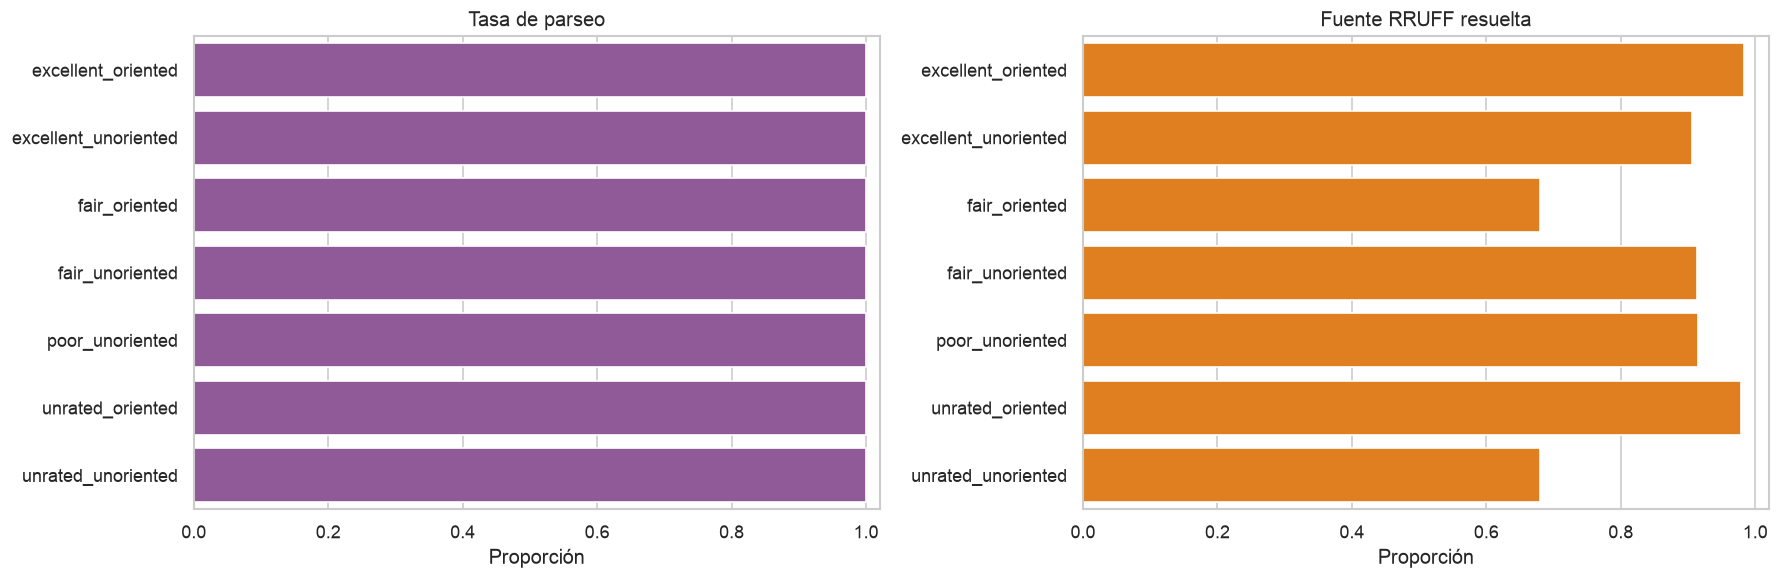

,files
source_id_status,
filename_header_agree,26202
filename_header_conflict,1607
missing,295
header_only,9
filename_only,2


,files
rejection_reason,


In [5]:
parse_summary = (manifest.groupby("domain", as_index=False)
    .agg(files=("spectrum_id","size"), parsed=("accepted_parse","sum"),
         resolved_sources=("source_id", lambda s: s.notna().sum()),
         unique_sources=("source_id","nunique"), minerals=("label","nunique")))
parse_summary["parse_rate"] = parse_summary["parsed"] / parse_summary["files"]
parse_summary["source_resolution_rate"] = parse_summary["resolved_sources"] / parse_summary["files"]
display(parse_summary.style.format({"parse_rate":"{:.2%}", "source_resolution_rate":"{:.2%}"}))
parse_summary.to_csv(OUTPUT_DIR / "parse_and_source_summary.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=parse_summary, y="domain", x="parse_rate", ax=axes[0], color="#984ea3")
axes[0].set_xlim(0,1.02); axes[0].set(title="Tasa de parseo", xlabel="Proporción", ylabel="")
sns.barplot(data=parse_summary, y="domain", x="source_resolution_rate", ax=axes[1], color="#ff7f00")
axes[1].set_xlim(0,1.02); axes[1].set(title="Fuente RRUFF resuelta", xlabel="Proporción", ylabel="")
plt.tight_layout(); plt.show()

display(manifest["source_id_status"].value_counts(dropna=False).to_frame("files"))
display(manifest.loc[~manifest.accepted_parse, "rejection_reason"].value_counts().to_frame("files"))


## 5. RAW frente a Processed, láseres, ángulos y polarización

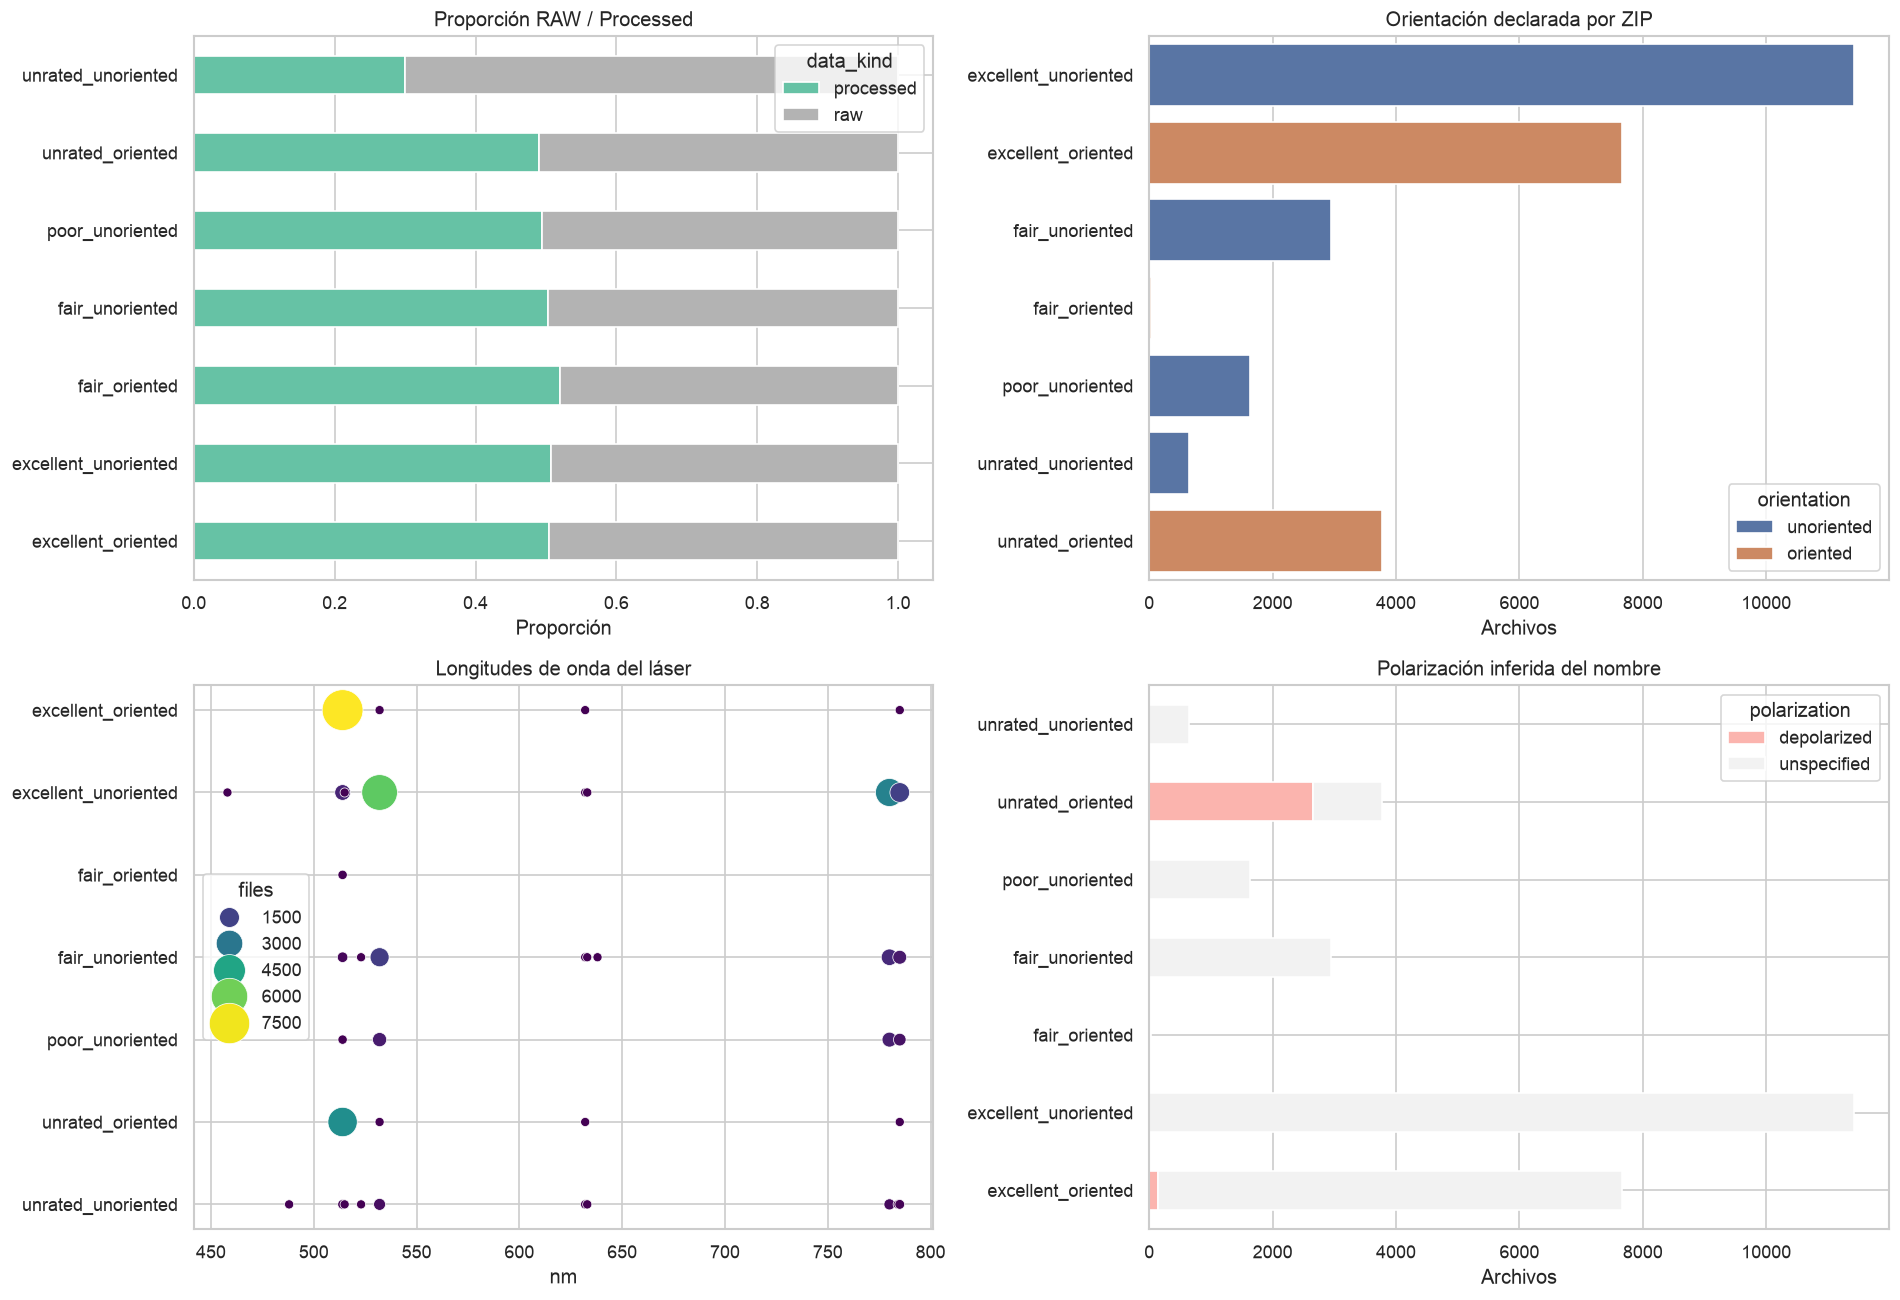

data_kind,processed,raw,All
domain,,,
excellent_oriented,3869,3799,7668
excellent_unoriented,5787,5628,11415
fair_oriented,13,12,25
fair_unoriented,1485,1466,2951
poor_unoriented,810,829,1639
unrated_oriented,1851,1927,3778
unrated_unoriented,192,447,639
All,14007,14108,28115


laser_nm,458.0,488.0,514.0,515.0,523.0,532.0,632.0,633.0,638.0,780.0,784.0,785.0,All
domain,,,,,,,,,,,,,
excellent_oriented,0,0,7651,0,0,3,2,0,0,0,0,6,7662
excellent_unoriented,2,0,785,1,0,5744,2,10,0,3380,0,1464,11388
fair_oriented,0,0,25,0,0,0,0,0,0,0,0,0,25
fair_unoriented,0,0,137,0,1,1352,3,1,2,915,0,530,2941
poor_unoriented,0,0,21,0,0,575,0,0,0,670,0,373,1639
unrated_oriented,0,0,3761,0,0,5,2,0,0,0,0,4,3772
unrated_unoriented,0,6,54,3,1,289,15,10,0,197,2,62,639
All,2,6,12434,4,2,7968,24,21,2,5162,2,2439,28066


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
pd.crosstab(manifest.domain, manifest.data_kind, normalize="index").plot.barh(stacked=True, ax=axes[0,0], colormap="Set2")
axes[0,0].set(title="Proporción RAW / Processed", xlabel="Proporción", ylabel="")
sns.countplot(data=manifest, y="domain", hue="orientation", ax=axes[0,1])
axes[0,1].set(title="Orientación declarada por ZIP", xlabel="Archivos", ylabel="")
laser_counts = manifest.dropna(subset=["laser_nm"]).groupby(["domain","laser_nm"]).size().reset_index(name="files")
sns.scatterplot(data=laser_counts, x="laser_nm", y="domain", size="files", hue="files", sizes=(30,600), ax=axes[1,0], palette="viridis")
axes[1,0].set(title="Longitudes de onda del láser", xlabel="nm", ylabel="")
pol = pd.crosstab(manifest.domain, manifest.polarization)
pol.plot.barh(stacked=True, ax=axes[1,1], colormap="Pastel1")
axes[1,1].set(title="Polarización inferida del nombre", xlabel="Archivos", ylabel="")
plt.tight_layout(); plt.show()

display(pd.crosstab(manifest["domain"], manifest["data_kind"], margins=True))
display(pd.crosstab(manifest["domain"], manifest["laser_nm"], margins=True))


## 6. Minerales, fuentes y desbalance

Se comparan tres cantidades distintas: archivos, fuentes únicas y clases. Muchos espectros de una sola fuente aumentan el volumen, pero no necesariamente la diversidad independiente.

,domain,spectra,minerals,sources
0,excellent_oriented,7668,216,442
1,excellent_unoriented,11415,1958,2882
2,fair_oriented,25,4,4
3,fair_unoriented,2951,889,1011
4,poor_unoriented,1639,533,603
5,unrated_oriented,3778,217,481
6,unrated_unoriented,639,271,197


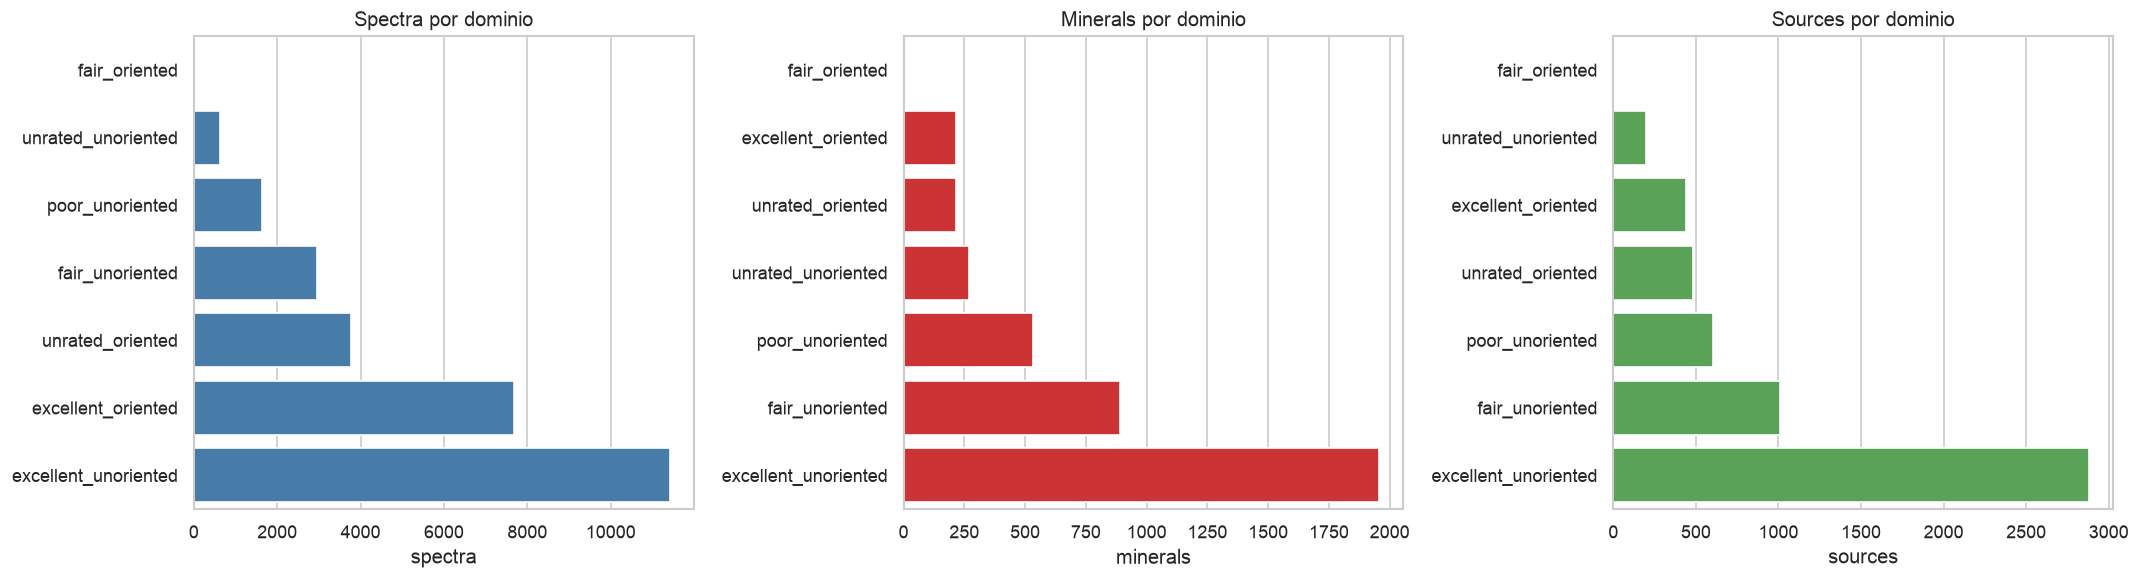

,spectra,sources,domains
label,,,
Diopside,377,10,6
Axinite-(Fe),315,6,3
Fluorapatite,274,13,6
Epidote,250,11,3
Beryl,247,14,6
Albite,230,7,3
Microcline,224,6,5
Forsterite,220,11,4
Enstatite,217,11,6


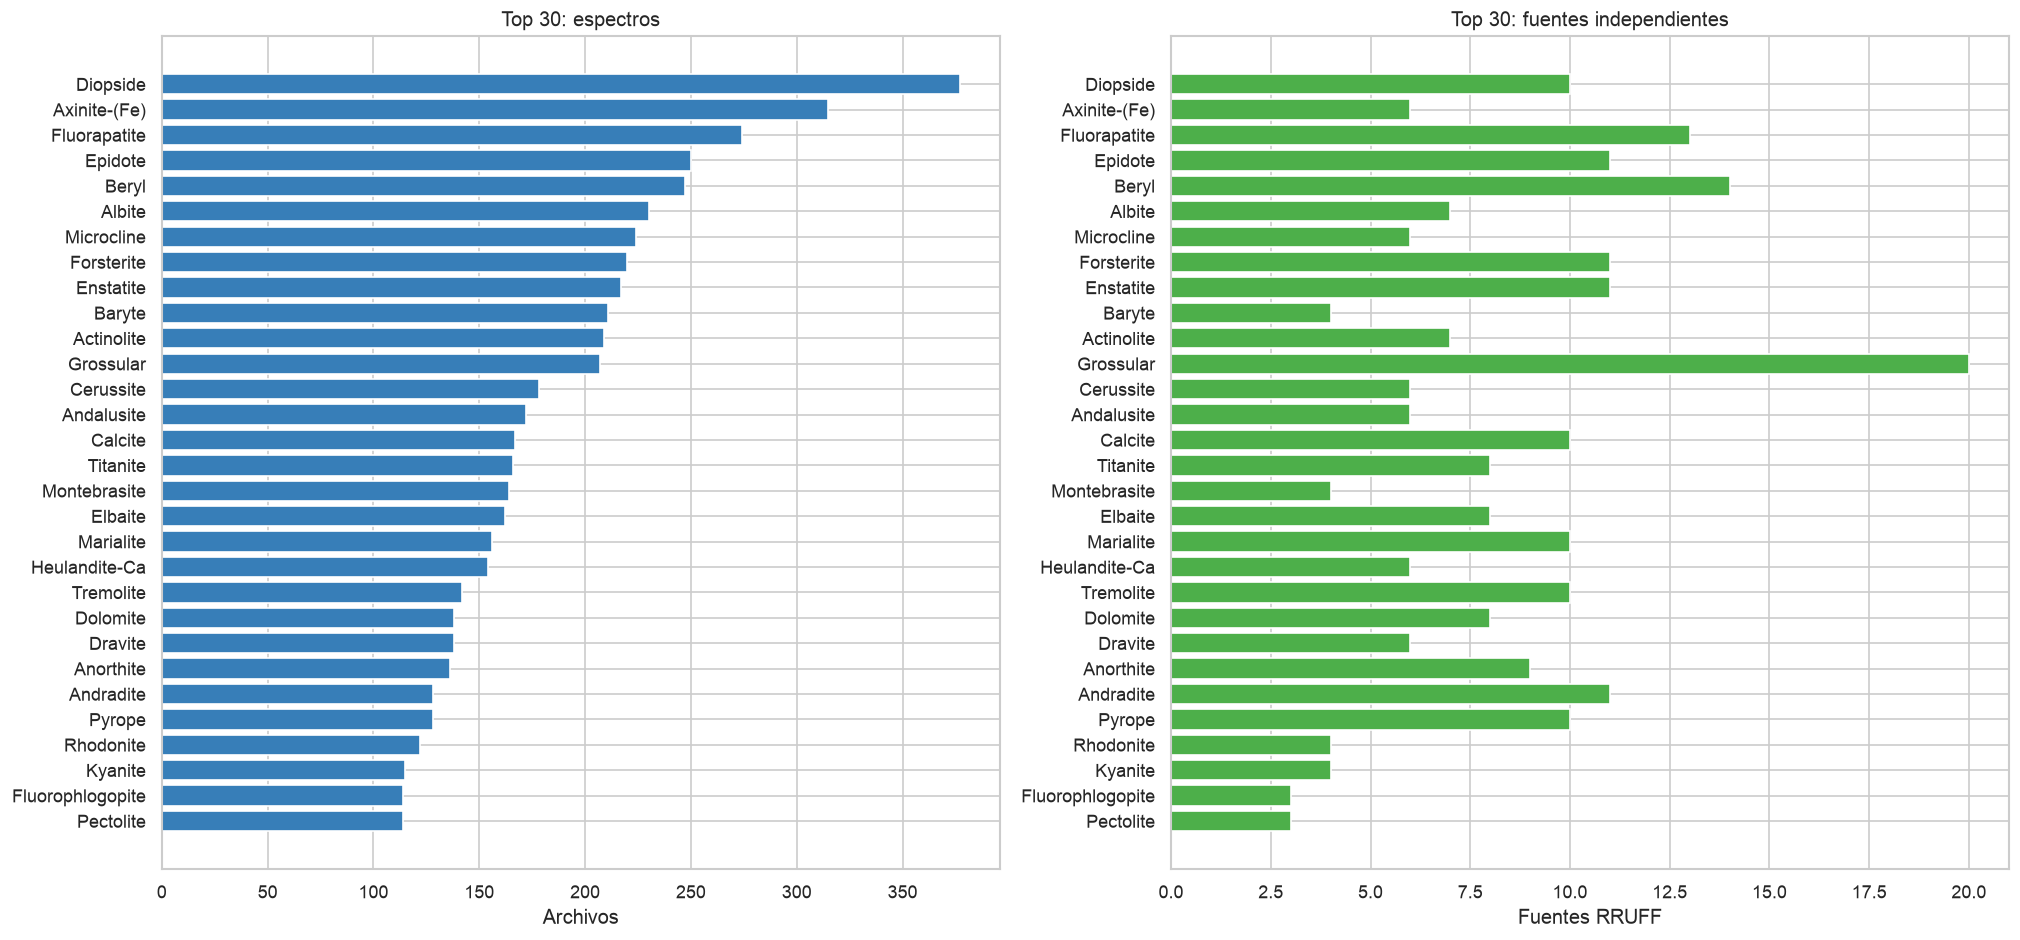

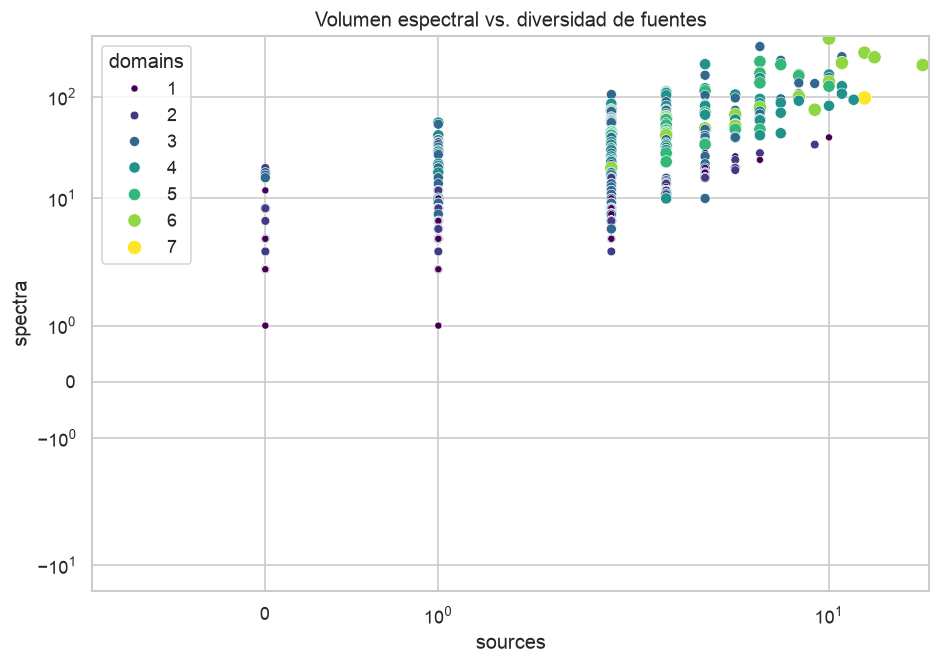


[SOLO PANTALLA] RRUFF_7_ZIPS_EDA_RESULTS/class_support_global.csv | dimensiones: (2509, 3)


,spectra,sources,domains
label,,,
Diopside,377,10,6
Axinite-(Fe),315,6,3
Fluorapatite,274,13,6
Epidote,250,11,3
Beryl,247,14,6
Albite,230,7,3
Microcline,224,6,5
Forsterite,220,11,4
Enstatite,217,11,6


In [7]:
ok = manifest[manifest.accepted_parse].copy()
summary = (ok.groupby("domain", as_index=False)
           .agg(spectra=("spectrum_id","size"), minerals=("label","nunique"), sources=("source_id","nunique")))
display(summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, color in zip(axes, ["spectra","minerals","sources"], ["#377eb8","#e41a1c","#4daf4a"]):
    sns.barplot(data=summary.sort_values(col), y="domain", x=col, ax=ax, color=color)
    ax.set(title=col.capitalize()+" por dominio", ylabel="")
plt.tight_layout(); plt.show()

class_counts = ok.groupby("label").agg(spectra=("spectrum_id","size"), sources=("source_id","nunique"), domains=("domain","nunique")).sort_values("spectra", ascending=False)
display(class_counts.head(TOP_N_CLASSES))

fig, axes = plt.subplots(1, 2, figsize=(17, 8))
top = class_counts.head(TOP_N_CLASSES).sort_values("spectra")
axes[0].barh(top.index, top.spectra, color="#377eb8"); axes[0].set(title=f"Top {TOP_N_CLASSES}: espectros", xlabel="Archivos")
axes[1].barh(top.index, top.sources, color="#4daf4a"); axes[1].set(title=f"Top {TOP_N_CLASSES}: fuentes independientes", xlabel="Fuentes RRUFF")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9,6))
sns.scatterplot(data=class_counts.reset_index(), x="sources", y="spectra", hue="domains", size="domains", palette="viridis", ax=ax)
ax.set(xscale="symlog", yscale="symlog", title="Volumen espectral vs. diversidad de fuentes")
plt.show()

class_counts.to_csv(OUTPUT_DIR / "class_support_global.csv")


## 7. Clases escasas y viabilidad de particiones agrupadas

Para reservar al menos una fuente por clase en entrenamiento, validación y test se requieren **tres fuentes fiables por clase**. Esta auditoría no crea el split; solo cuantifica su viabilidad.

,criterion,classes
0,≥1 fuente,2329
1,≥2 fuentes,738
2,≥3 fuentes,259
3,≥5 fuentes,67
4,≥10 fuentes,17


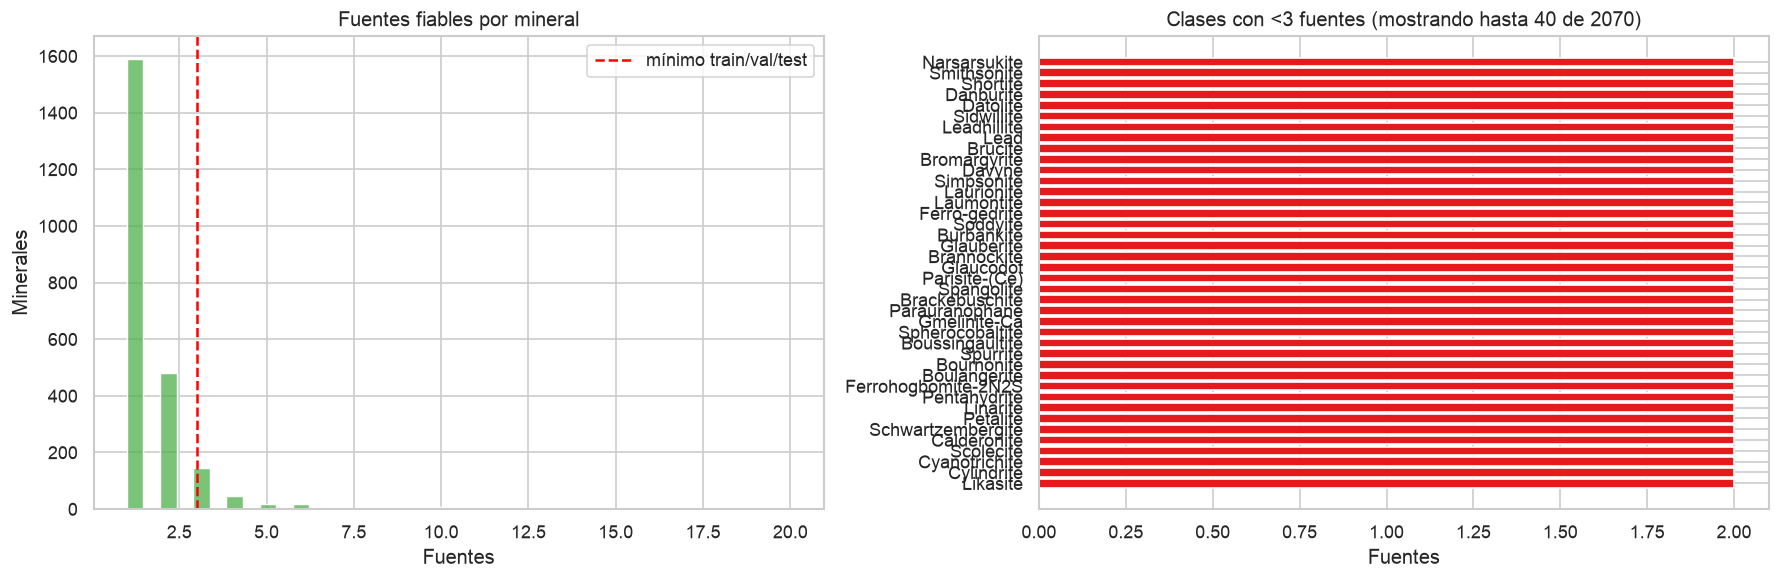


[SOLO PANTALLA] RRUFF_7_ZIPS_EDA_RESULTS/classes_with_fewer_than_3_sources.csv | dimensiones: (2070,)


label
Abellaite             1
Miguelromeroite       1
Microsommite          1
Microlite             1
Miassite              1
Meyerhofferite        1
Meurigite-K           1
Metavivianite         1
Metavariscite         1
Metauroxite           1
MetauranocirciteII    1
Metauranocircite      1
Mikenewite            1
Metastibnite          1
Metarauchite          1
Metamunirite          1
Metalodevite          1
Metakottigite         1
Metahewettite         1
Metaheinrichite       1
Metacinnabar          1
Metaborite            1
Merwinite             1
Merrillite            1
Merlinoite            1
Metaschoderite        1
Mercury               1
Minyulite             1
Mixite                1
Namuwite              1
Nambulite             1
Nalivkinite           1
Nahcolite             1
Nagelschmidtite       1
Nacrite               1
Nabokoite             1
Naalasite             1
Mushistonite          1
Murphyite             1
Moxuanxueite          1
Name: n_sources, dtype: int64

In [8]:
source_per_class = ok.dropna(subset=["source_id"]).groupby("label")["source_id"].nunique()
threshold_table = pd.DataFrame({
    "criterion": ["≥1 fuente", "≥2 fuentes", "≥3 fuentes", "≥5 fuentes", "≥10 fuentes"],
    "classes": [(source_per_class >= n).sum() for n in [1,2,3,5,10]],
})
display(threshold_table)

fig, axes = plt.subplots(1, 2, figsize=(15,5))
sns.histplot(source_per_class, bins=40, ax=axes[0], color="#4daf4a")
axes[0].axvline(3, color="red", linestyle="--", label="mínimo train/val/test"); axes[0].legend()
axes[0].set(title="Fuentes fiables por mineral", xlabel="Fuentes", ylabel="Minerales")
scarce = source_per_class[source_per_class < 3].sort_values()
axes[1].barh(scarce.index[-40:], scarce.tail(40), color="#e41a1c")
axes[1].set(title=f"Clases con <3 fuentes (mostrando hasta 40 de {len(scarce)})", xlabel="Fuentes")
plt.tight_layout(); plt.show()

scarce.rename("n_sources").to_csv(OUTPUT_DIR / "classes_with_fewer_than_3_sources.csv")


## 8. Cobertura cruzada entre dominios

Una clase o fuente presente en varios ZIP conecta dominios de calidad/orientación. Si se divide por archivo y no por fuente, esta estructura puede causar fuga.

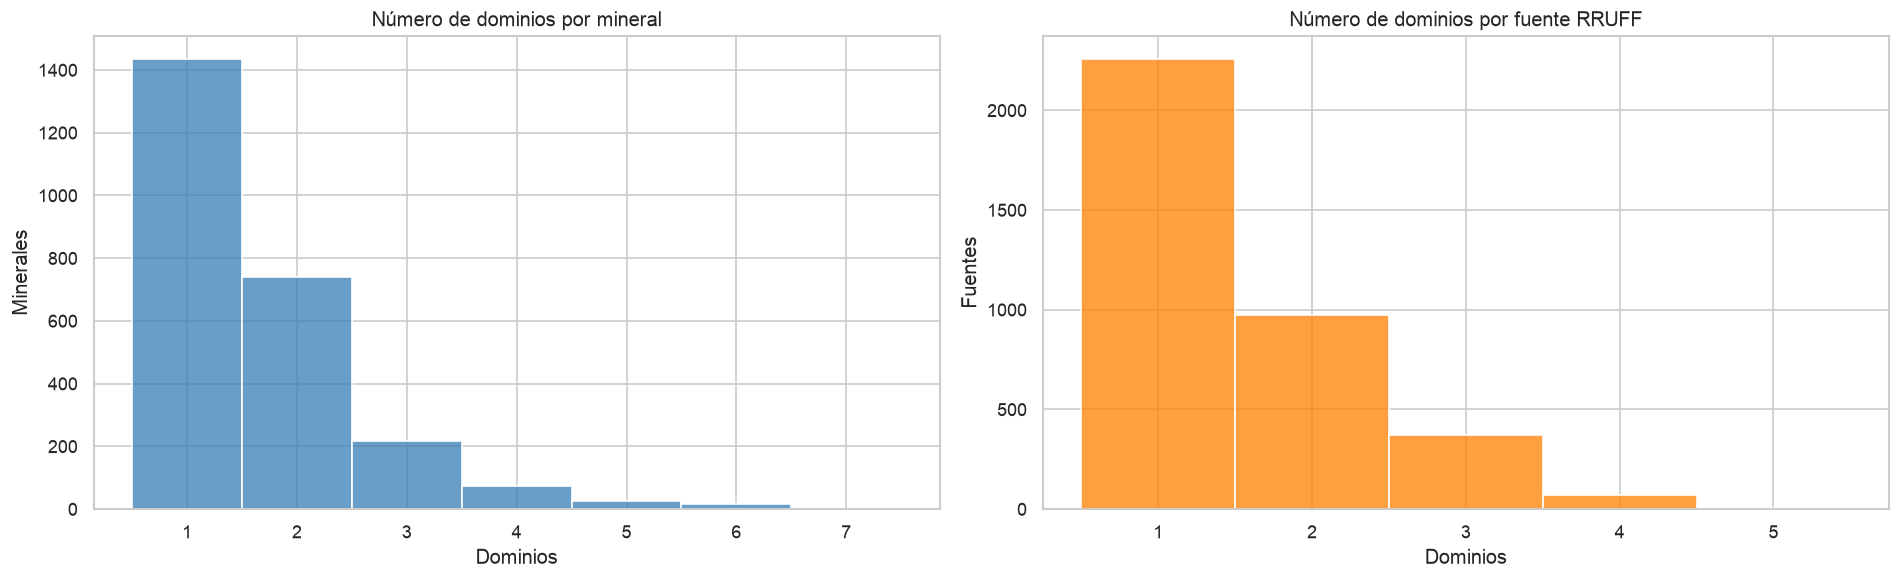

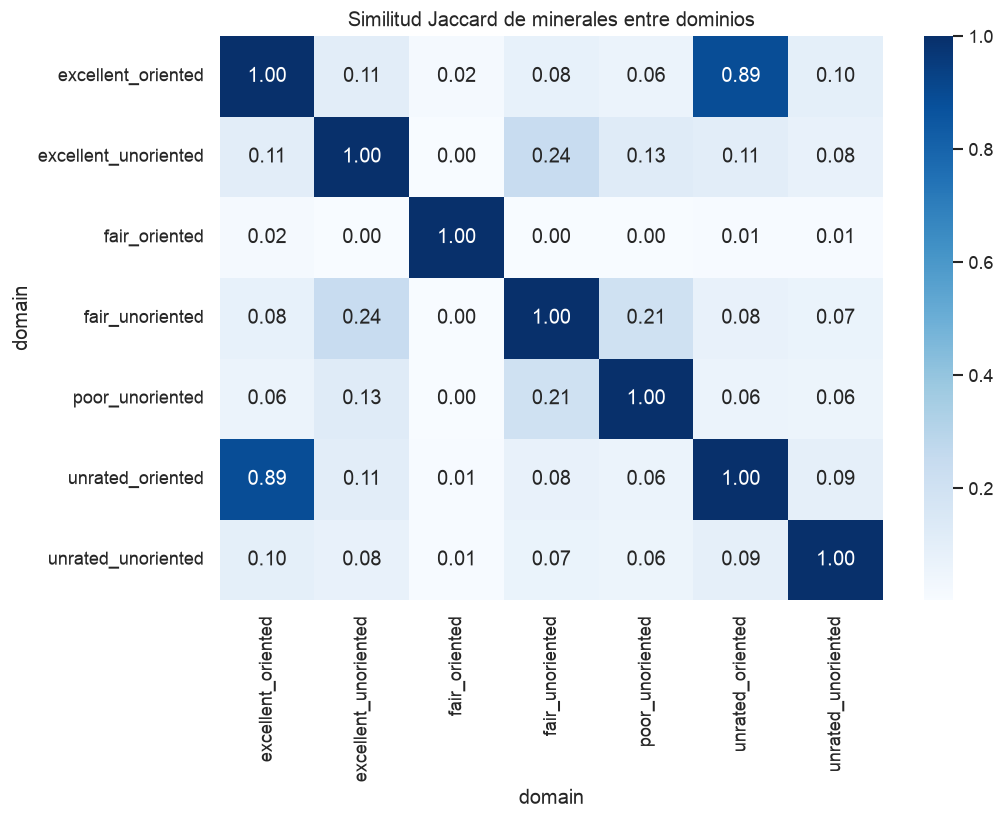


[SOLO PANTALLA] RRUFF_7_ZIPS_EDA_RESULTS/class_domain_presence.csv | dimensiones: (2509, 7)


domain,excellent_oriented,excellent_unoriented,fair_oriented,fair_unoriented,poor_unoriented,unrated_oriented,unrated_unoriented
label,,,,,,,
Abellaite,0,1,0,0,0,0,0
Abelsonite,0,1,0,1,0,0,0
Abhurite,0,1,0,0,0,0,0
Abramovite,0,0,0,0,1,0,1
Acanthite,0,0,0,0,1,0,1
Actinolite,1,1,0,1,0,1,1
Adachiite,0,1,0,0,0,0,0
Adamite,1,1,0,0,0,1,0
Adamsite-(Y),0,1,0,0,1,0,0



[SOLO PANTALLA] RRUFF_7_ZIPS_EDA_RESULTS/source_domain_presence.csv | dimensiones: (3677, 7)


domain,excellent_oriented,excellent_unoriented,fair_oriented,fair_unoriented,poor_unoriented,unrated_oriented,unrated_unoriented
source_id,,,,,,,
R040001,0,1,0,0,0,1,0
R040002,1,1,0,0,0,1,0
R040003,1,1,0,0,0,1,0
R040004,1,1,0,0,0,1,0
R040005,1,1,0,1,0,1,0
R040006,1,1,0,0,0,1,0
R040007,1,1,0,0,0,1,0
R040008,0,1,0,1,0,0,0
R040009,1,1,0,0,0,1,0


In [9]:
class_domain = pd.crosstab(ok.label, ok.domain).astype(bool).astype(int)
source_domain = pd.crosstab(ok.dropna(subset=["source_id"]).source_id, ok.dropna(subset=["source_id"]).domain).astype(bool).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16,5))
sns.histplot(class_domain.sum(axis=1), discrete=True, ax=axes[0], color="#377eb8")
axes[0].set(title="Número de dominios por mineral", xlabel="Dominios", ylabel="Minerales")
sns.histplot(source_domain.sum(axis=1), discrete=True, ax=axes[1], color="#ff7f00")
axes[1].set(title="Número de dominios por fuente RRUFF", xlabel="Dominios", ylabel="Fuentes")
plt.tight_layout(); plt.show()

overlap = pd.DataFrame(index=class_domain.columns, columns=class_domain.columns, dtype=float)
for a in class_domain.columns:
    A = set(class_domain.index[class_domain[a] == 1])
    for b in class_domain.columns:
        B = set(class_domain.index[class_domain[b] == 1])
        overlap.loc[a,b] = len(A & B) / max(len(A | B), 1)
plt.figure(figsize=(9,7)); sns.heatmap(overlap.astype(float), annot=True, fmt=".2f", cmap="Blues")
plt.title("Similitud Jaccard de minerales entre dominios"); plt.tight_layout(); plt.show()

class_domain.to_csv(OUTPUT_DIR / "class_domain_presence.csv")
source_domain.to_csv(OUTPUT_DIR / "source_domain_presence.csv")


## 9. Duplicados exactos y coherencia fuente–etiqueta

In [10]:
dup_groups = manifest.groupby("sha256").filter(lambda g: len(g) > 1).sort_values("sha256")
dup_summary = (dup_groups.groupby("sha256", as_index=False)
               .agg(copies=("spectrum_id","size"), domains=("domain","nunique"),
                    labels=("label","nunique"), members=("filename", lambda s: " | ".join(s.head(5)))))
print("Grupos de bytes duplicados:", len(dup_summary))
print("Copias adicionales:", int((dup_summary.copies - 1).sum()) if len(dup_summary) else 0)
display(dup_summary.head(20))

source_label = (ok.dropna(subset=["source_id"]).groupby("source_id")
                .agg(n_labels=("label","nunique"), labels=("label", lambda s: " | ".join(sorted(set(s)))),
                     spectra=("spectrum_id","size"), domains=("domain","nunique")))
conflicts = source_label[source_label.n_labels > 1].sort_values("n_labels", ascending=False)
print("Fuentes asociadas a más de una etiqueta:", len(conflicts))
display(conflicts.head(30))

dup_groups.to_csv(OUTPUT_DIR / "exact_duplicate_members.csv", index=False)
conflicts.to_csv(OUTPUT_DIR / "source_label_conflicts.csv")


Grupos de bytes duplicados: 16
Copias adicionales: 16


,sha256,copies,domains,labels,members
0,17ad51cea7b9a9d245ed9dbcba04adea065f7285ce1283...,2,1,1,Calcite__R050009-3__Raman__514__0-000__depolar...
1,3215f776d3c8eb7489c874c26c1941caf143f6e8eb75d3...,2,2,1,Augite__R061086-4__Raman__514__90-000__ccw__Ra...
2,426f0f31f6c1625b1daf383871926cba440399f61d381d...,2,1,1,Baddeleyite__R060016-3__Raman__514__0-000____R...
3,4c4e05dcfe04d5575657a7c5d7304d84c85c06feded390...,2,1,1,Forsterite__R060539-5__Raman__514__90-000__ccw...
4,6cfde17d262493b899371a45698449e5a7e6d429324fe9...,2,1,1,Pyrope__R050446-3__Raman__514__0-000____Raman_...
5,6da97731c820f191d32c3b37255ff6d8b9fe2bd255aeae...,2,1,1,Talc__R050087-7__Raman__514__45-000__ccw__Rama...
6,82cca24642ab104d957d1125f37c3ecddf6069ebecc118...,2,2,1,Margarosanite__R120111__Raman__532______Raman_...
7,8d37941f3aa0c961cdf13ccf4f66266b22fa7d42751dd2...,2,1,1,Dolomite__R050241-3__Raman__514__90-000__ccw__...
8,987441311db56eff755bdf183cb77a8fc87e22cf45a472...,2,1,1,Diopside__R060085-5__Raman__514__0-000__depola...
9,b1d488f58d23e1bd8e24044d9cfa1e04af9683c52b3aad...,2,1,1,Talc__R050087-6__Raman__514__45-000__ccw__Rama...


Fuentes asociadas a más de una etiqueta: 2


,n_labels,labels,spectra,domains
source_id,,,,
R050194,2,Bromellite | Fluorapatite,24,5
R230009,2,Molybdomenite | unknown,4,2



[SOLO PANTALLA] RRUFF_7_ZIPS_EDA_RESULTS/exact_duplicate_members.csv | dimensiones: (32, 28)


,spectrum_id,domain,quality,orientation,member,filename,label,source_id,source_id_status,source_id_filename,source_id_header,laser_nm,data_kind,polarization,angle_deg,accepted_parse,rejection_reason,sha256,bytes,n_points,min_shift,max_shift,span_shift,median_step,min_intensity,max_intensity,intensity_range,negative_fraction
13498,S0013498,excellent_oriented,excellent,oriented,Calcite__R050009-3__Raman__514__0-000__depolar...,Calcite__R050009-3__Raman__514__0-000__depolar...,Calcite,R050009,filename_header_agree,R050009,R050009,514.0,raw,depolarized,0.0,True,None,17ad51cea7b9a9d245ed9dbcba04adea065f7285ce1283...,27315,1328,74.61800,1577.783,1503.16500,1.1310,1935.0,48082.0000,46147.0000,0.0
13502,S0013502,excellent_oriented,excellent,oriented,Calcite__R050009-3__Raman__514__90-000__ccw__R...,Calcite__R050009-3__Raman__514__90-000__ccw__R...,Calcite,R050009,filename_header_agree,R050009,R050009,514.0,raw,unspecified,90.0,True,None,17ad51cea7b9a9d245ed9dbcba04adea065f7285ce1283...,27315,1328,74.61800,1577.783,1503.16500,1.1310,1935.0,48082.0000,46147.0000,0.0
12519,S0012519,excellent_oriented,excellent,oriented,Augite__R061086-4__Raman__514__90-000__ccw__Ra...,Augite__R061086-4__Raman__514__90-000__ccw__Ra...,Augite,R061086,filename_header_agree,R061086,R061086,514.0,raw,unspecified,90.0,True,None,3215f776d3c8eb7489c874c26c1941caf143f6e8eb75d3...,25862,1251,131.64900,1545.830,1414.18100,1.1300,4873.0,14006.0000,9133.0000,0.0
24742,S0024742,unrated_oriented,unrated,oriented,Augite__R061086-4__Raman__514__0-000__depolari...,Augite__R061086-4__Raman__514__0-000__depolari...,Augite,R061086,filename_header_agree,R061086,R061086,514.0,raw,depolarized,0.0,True,None,3215f776d3c8eb7489c874c26c1941caf143f6e8eb75d3...,25862,1251,131.64900,1545.830,1414.18100,1.1300,4873.0,14006.0000,9133.0000,0.0
12827,S0012827,excellent_oriented,excellent,oriented,Baddeleyite__R060016-3__Raman__514__0-000____R...,Baddeleyite__R060016-3__Raman__514__0-000____R...,Baddeleyite,R060016,filename_header_agree,R060016,R060016,514.0,raw,unspecified,0.0,True,None,426f0f31f6c1625b1daf383871926cba440399f61d381d...,25569,1241,162.76700,1561.963,1399.19600,1.1285,9782.0,19909.0000,10127.0000,0.0
12829,S0012829,excellent_oriented,excellent,oriented,Baddeleyite__R060016-3__Raman__514__45-000__cc...,Baddeleyite__R060016-3__Raman__514__45-000__cc...,Baddeleyite,R060016,filename_header_agree,R060016,R060016,514.0,raw,unspecified,45.0,True,None,426f0f31f6c1625b1daf383871926cba440399f61d381d...,25569,1241,162.76700,1561.963,1399.19600,1.1285,9782.0,19909.0000,10127.0000,0.0
15939,S0015939,excellent_oriented,excellent,oriented,Forsterite__R060539-5__Raman__514__90-000__ccw...,Forsterite__R060539-5__Raman__514__90-000__ccw...,Forsterite,R060539,filename_header_agree,R060539,R060539,514.0,raw,unspecified,90.0,True,None,4c4e05dcfe04d5575657a7c5d7304d84c85c06feded390...,26195,1271,128.74200,1565.283,1436.54100,1.1310,889.0,56929.0000,56040.0000,0.0
15937,S0015937,excellent_oriented,excellent,oriented,Forsterite__R060539-5__Raman__514__45-000__ccw...,Forsterite__R060539-5__Raman__514__45-000__ccw...,Forsterite,R060539,filename_header_agree,R060539,R060539,514.0,raw,unspecified,45.0,True,None,4c4e05dcfe04d5575657a7c5d7304d84c85c06feded390...,26195,1271,128.74200,1565.283,1436.54100,1.1310,889.0,56929.0000,56040.0000,0.0
27333,S0027333,unrated_oriented,unrated,oriented,Pyrope__R050446-3__Raman__514__0-000____Raman_...,Pyrope__R050446-3__Raman__514__0-000____Raman_...,Pyrope,R050446,filename_header_agree,R050446,R050446,514.0,raw,unspecified,0.0,True,None,6cfde17d262493b899371a45698449e5a7e6d429324fe9...,27570,1340,62.89900,1578.796,1515.89700,1.1290,51.0,56145.0000,56094.0000,0.0
27337,S0027337,unrated_oriented,unrated,oriented,Pyrope__R050446-3__Raman__514__45-000__ccw__Ra...,Pyrope__R050446-3__Raman__514__45-000__ccw__Ra...,Pyrope,R050446,filename_header_agree,R050446,R050446,514.0,raw,unspecified,45.0,True,None,6cfde17d262493b899371a45698449e5a7e6d429324fe9...,27570,1340,62.89900,


[SOLO PANTALLA] RRUFF_7_ZIPS_EDA_RESULTS/source_label_conflicts.csv | dimensiones: (2, 4)


,n_labels,labels,spectra,domains
source_id,,,,
R050194,2,Bromellite | Fluorapatite,24,5
R230009,2,Molybdomenite | unknown,4,2


## 10. Rango Raman, densidad de muestreo e intensidad

Estas distribuciones determinan qué intervalo común puede interpolarse sin extrapolar. Las intensidades se muestran en escala logarítmica porque RAW y Processed pueden usar escalas muy diferentes.

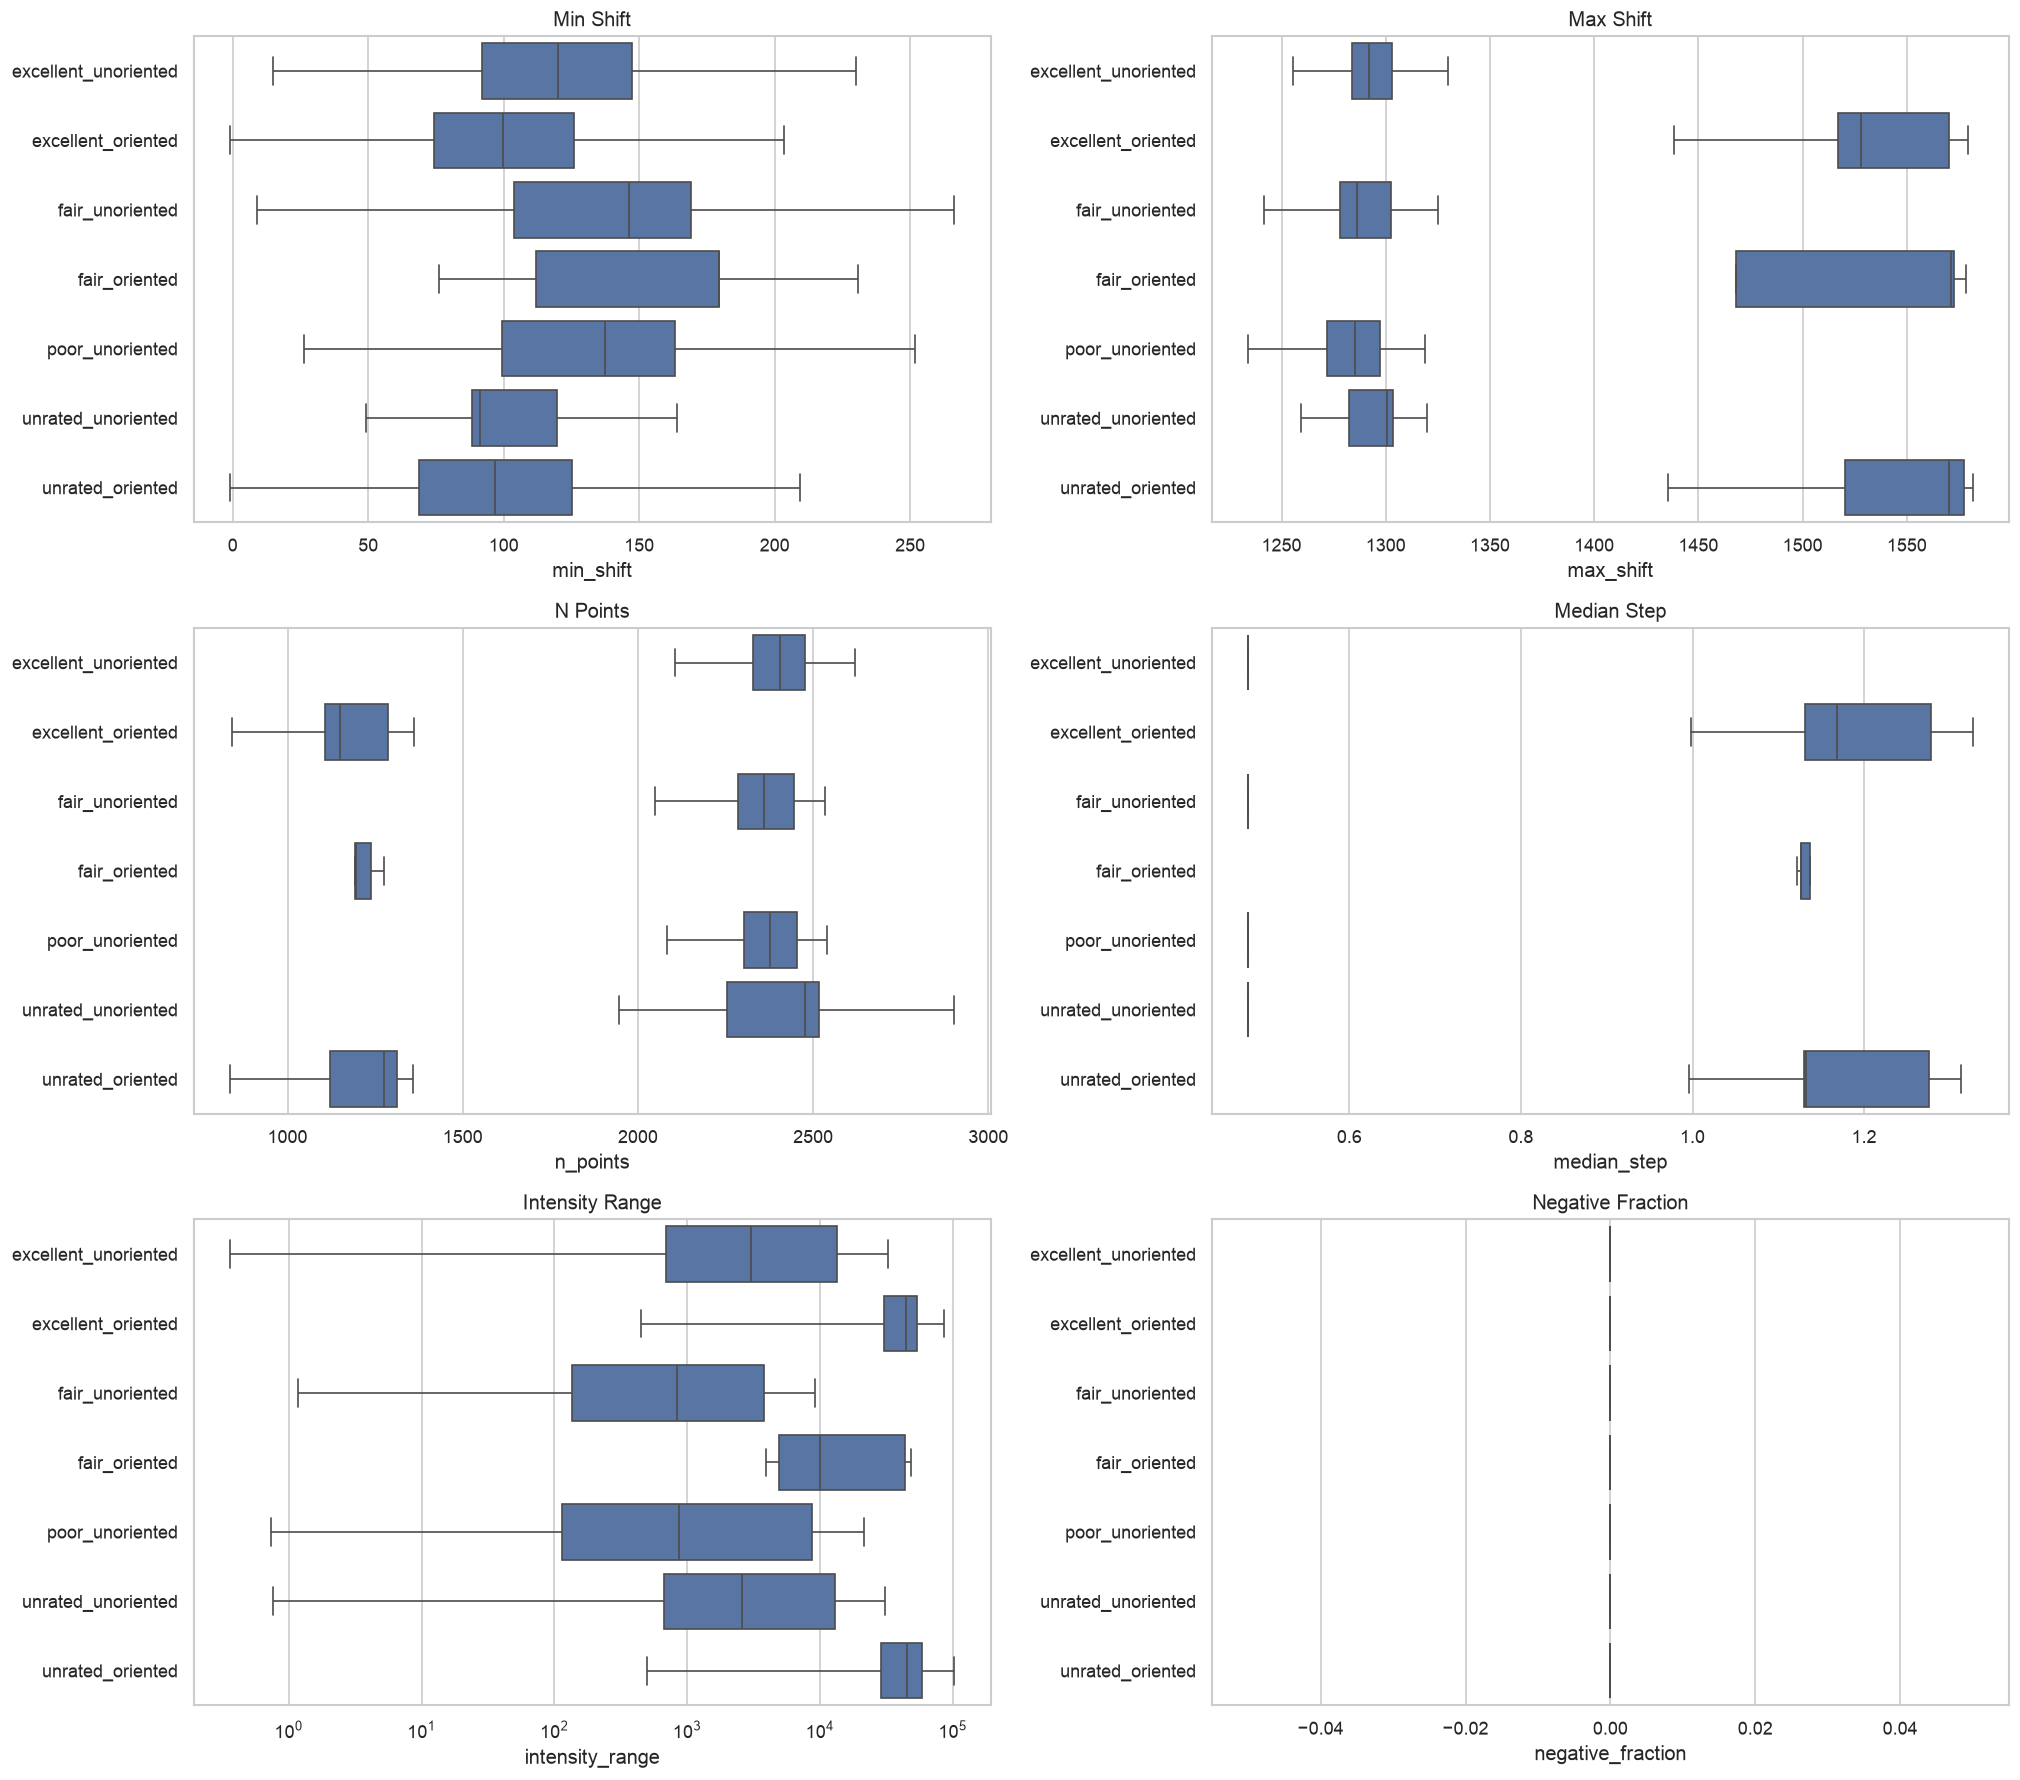

min_shift  max_shift  n_points  median_step
domain                                                                
excellent_oriented   0.05      0.000   1269.813     912.0        1.125
                     0.25     74.399   1517.094    1108.0        1.131
                     0.50     99.649   1527.923    1150.0        1.169
                     0.75    125.959   1570.384    1288.0        1.278
                     0.95    192.956   1572.435    1340.0        1.292
excellent_unoriented 0.05     87.582   1236.155    1105.7        0.482
                     0.25     92.025   1283.955    2328.0        0.482
                     0.50    119.953   1291.886    2406.0        0.482
                     0.75    147.425   1303.016    2477.0        0.482
                     0.95    180.709   1515.648    2516.0        1.279
fair_oriented        0.05     83.137   1467.936    1192.0        1.122
                     0.25    111.855   1467.936    1192.0        1.127
                     0.50    179.505   1571.409    1195.0        1.127
                     0.75    179.505   1572.435    1238.0        1.137
                     0.95    230.832   1577.018    1318.0        1.137
fair_unoriented      0.05     89.362   1230.370    1229.5        0.482
                     0.25    103.684   1278.166    2285.0        0.482
                     0.50    146.090   1286.228    2361.0        0.482
                     0.75    169.253   1302.596    2444.5        0.482
                     0.95    203.790   1317.867    2516.0        1.000
poor_unoriented      0.05     89.301   1229.888    2160.0        0.482
                     0.25     99.295   1271.852    2302.0        0.482
                     0.50    137.388   1285.324    2376.0        0.482
                     0.75    163.347   1297.207    2455.0        0.482
                     0.95    201.053   1312.564    2494.2        0.482
unrated_oriented     0.05      0.000   1325.163     958.0        1.126
                     0.25     68.847   1520.288    1121.0        1.130
                     0.50     96.621   1570.384    1275.0        1.132
                     0.75    125.295   1577.372    1311.0        1.276
                     0.95    168.486   1579.273    1340.0        1.287
unrated_unoriented   0.05     70.725   1233.745     648.9        0.482
                     0.25     88.137   1282.268    2255.5        0.482
                     0.50     91.121   1300.660    2477.0        0.482
                     0.75    119.787   1303.531    2516.0        0.482
                     0.95    187.682   2004.258    2524.0        2.459


[SOLO PANTALLA] RRUFF_7_ZIPS_EDA_RESULTS/spectral_axis_quantiles.csv | dimensiones: (35, 4)


min_shift  max_shift  n_points  median_step
domain                                                                
excellent_oriented   0.05      0.000   1269.813     912.0        1.125
                     0.25     74.399   1517.094    1108.0        1.131
                     0.50     99.649   1527.923    1150.0        1.169
                     0.75    125.959   1570.384    1288.0        1.278
                     0.95    192.956   1572.435    1340.0        1.292
excellent_unoriented 0.05     87.582   1236.155    1105.7        0.482
                     0.25     92.025   1283.955    2328.0        0.482
                     0.50    119.953   1291.886    2406.0        0.482
                     0.75    147.425   1303.016    2477.0        0.482
                     0.95    180.709   1515.648    2516.0        1.279
fair_oriented        0.05     83.137   1467.936    1192.0        1.122
                     0.25    111.855   1467.936    1192.0        1.127
                     0.50    179.505   1571.409    1195.0        1.127
                     0.75    179.505   1572.435    1238.0        1.137
                     0.95    230.832   1577.018    1318.0        1.137
fair_unoriented      0.05     89.362   1230.370    1229.5        0.482
                     0.25    103.684   1278.166    2285.0        0.482
                     0.50    146.090   1286.228    2361.0        0.482
                     0.75    169.253   1302.596    2444.5        0.482
                     0.95    203.790   1317.867    2516.0        1.000
poor_unoriented      0.05     89.301   1229.888    2160.0        0.482
                     0.25     99.295   1271.852    2302.0        0.482
                     0.50    137.388   1285.324    2376.0        0.482
                     0.75    163.347   1297.207    2455.0        0.482
                     0.95    201.053   1312.564    2494.2        0.482
unrated_oriented     0.05      0.000   1325.163     958.0        1.126
                     0.25     68.847   1520.288    1121.0        1.130
                     0.50     96.621   1570.384    1275.0        1.132
                     0.75    125.295   1577.372    1311.0        1.276
                     0.95    168.486   1579.273    1340.0        1.287
unrated_unoriented   0.05     70.725   1233.745     648.9        0.482
                     0.25     88.137   1282.268    2255.5        0.482
                     0.50     91.121   1300.660    2477.0        0.482
                     0.75    119.787   1303.531    2516.0        0.482
                     0.95    187.682   2004.258    2524.0        2.459

In [11]:
metrics = ["min_shift","max_shift","n_points","median_step","intensity_range","negative_fraction"]
fig, axes = plt.subplots(3, 2, figsize=(17,15))
for ax, metric in zip(axes.ravel(), metrics):
    data = ok.replace([np.inf,-np.inf], np.nan).dropna(subset=[metric])
    sns.boxplot(data=data, y="domain", x=metric, showfliers=False, ax=ax)
    ax.set(title=metric.replace("_"," ").title(), ylabel="")
    if metric == "intensity_range": ax.set_xscale("log")
plt.tight_layout(); plt.show()

coverage = ok.groupby("domain")[["min_shift","max_shift","n_points","median_step"]].quantile([.05,.25,.5,.75,.95]).round(3)
display(coverage)
coverage.to_csv(OUTPUT_DIR / "spectral_axis_quantiles.csv")


## 11. Ejemplos espectrales por dominio

Cada curva se normaliza por su máximo absoluto **solo para visualización**. Así se compara la forma sin que la escala instrumental domine el gráfico.

/var/folders/7k/fp9wzk9j49b90hn85_mtsxvc0000gn/T/ipykernel_24941/52212091.py:11: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/opt/anaconda3/envs/raman-cnn/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


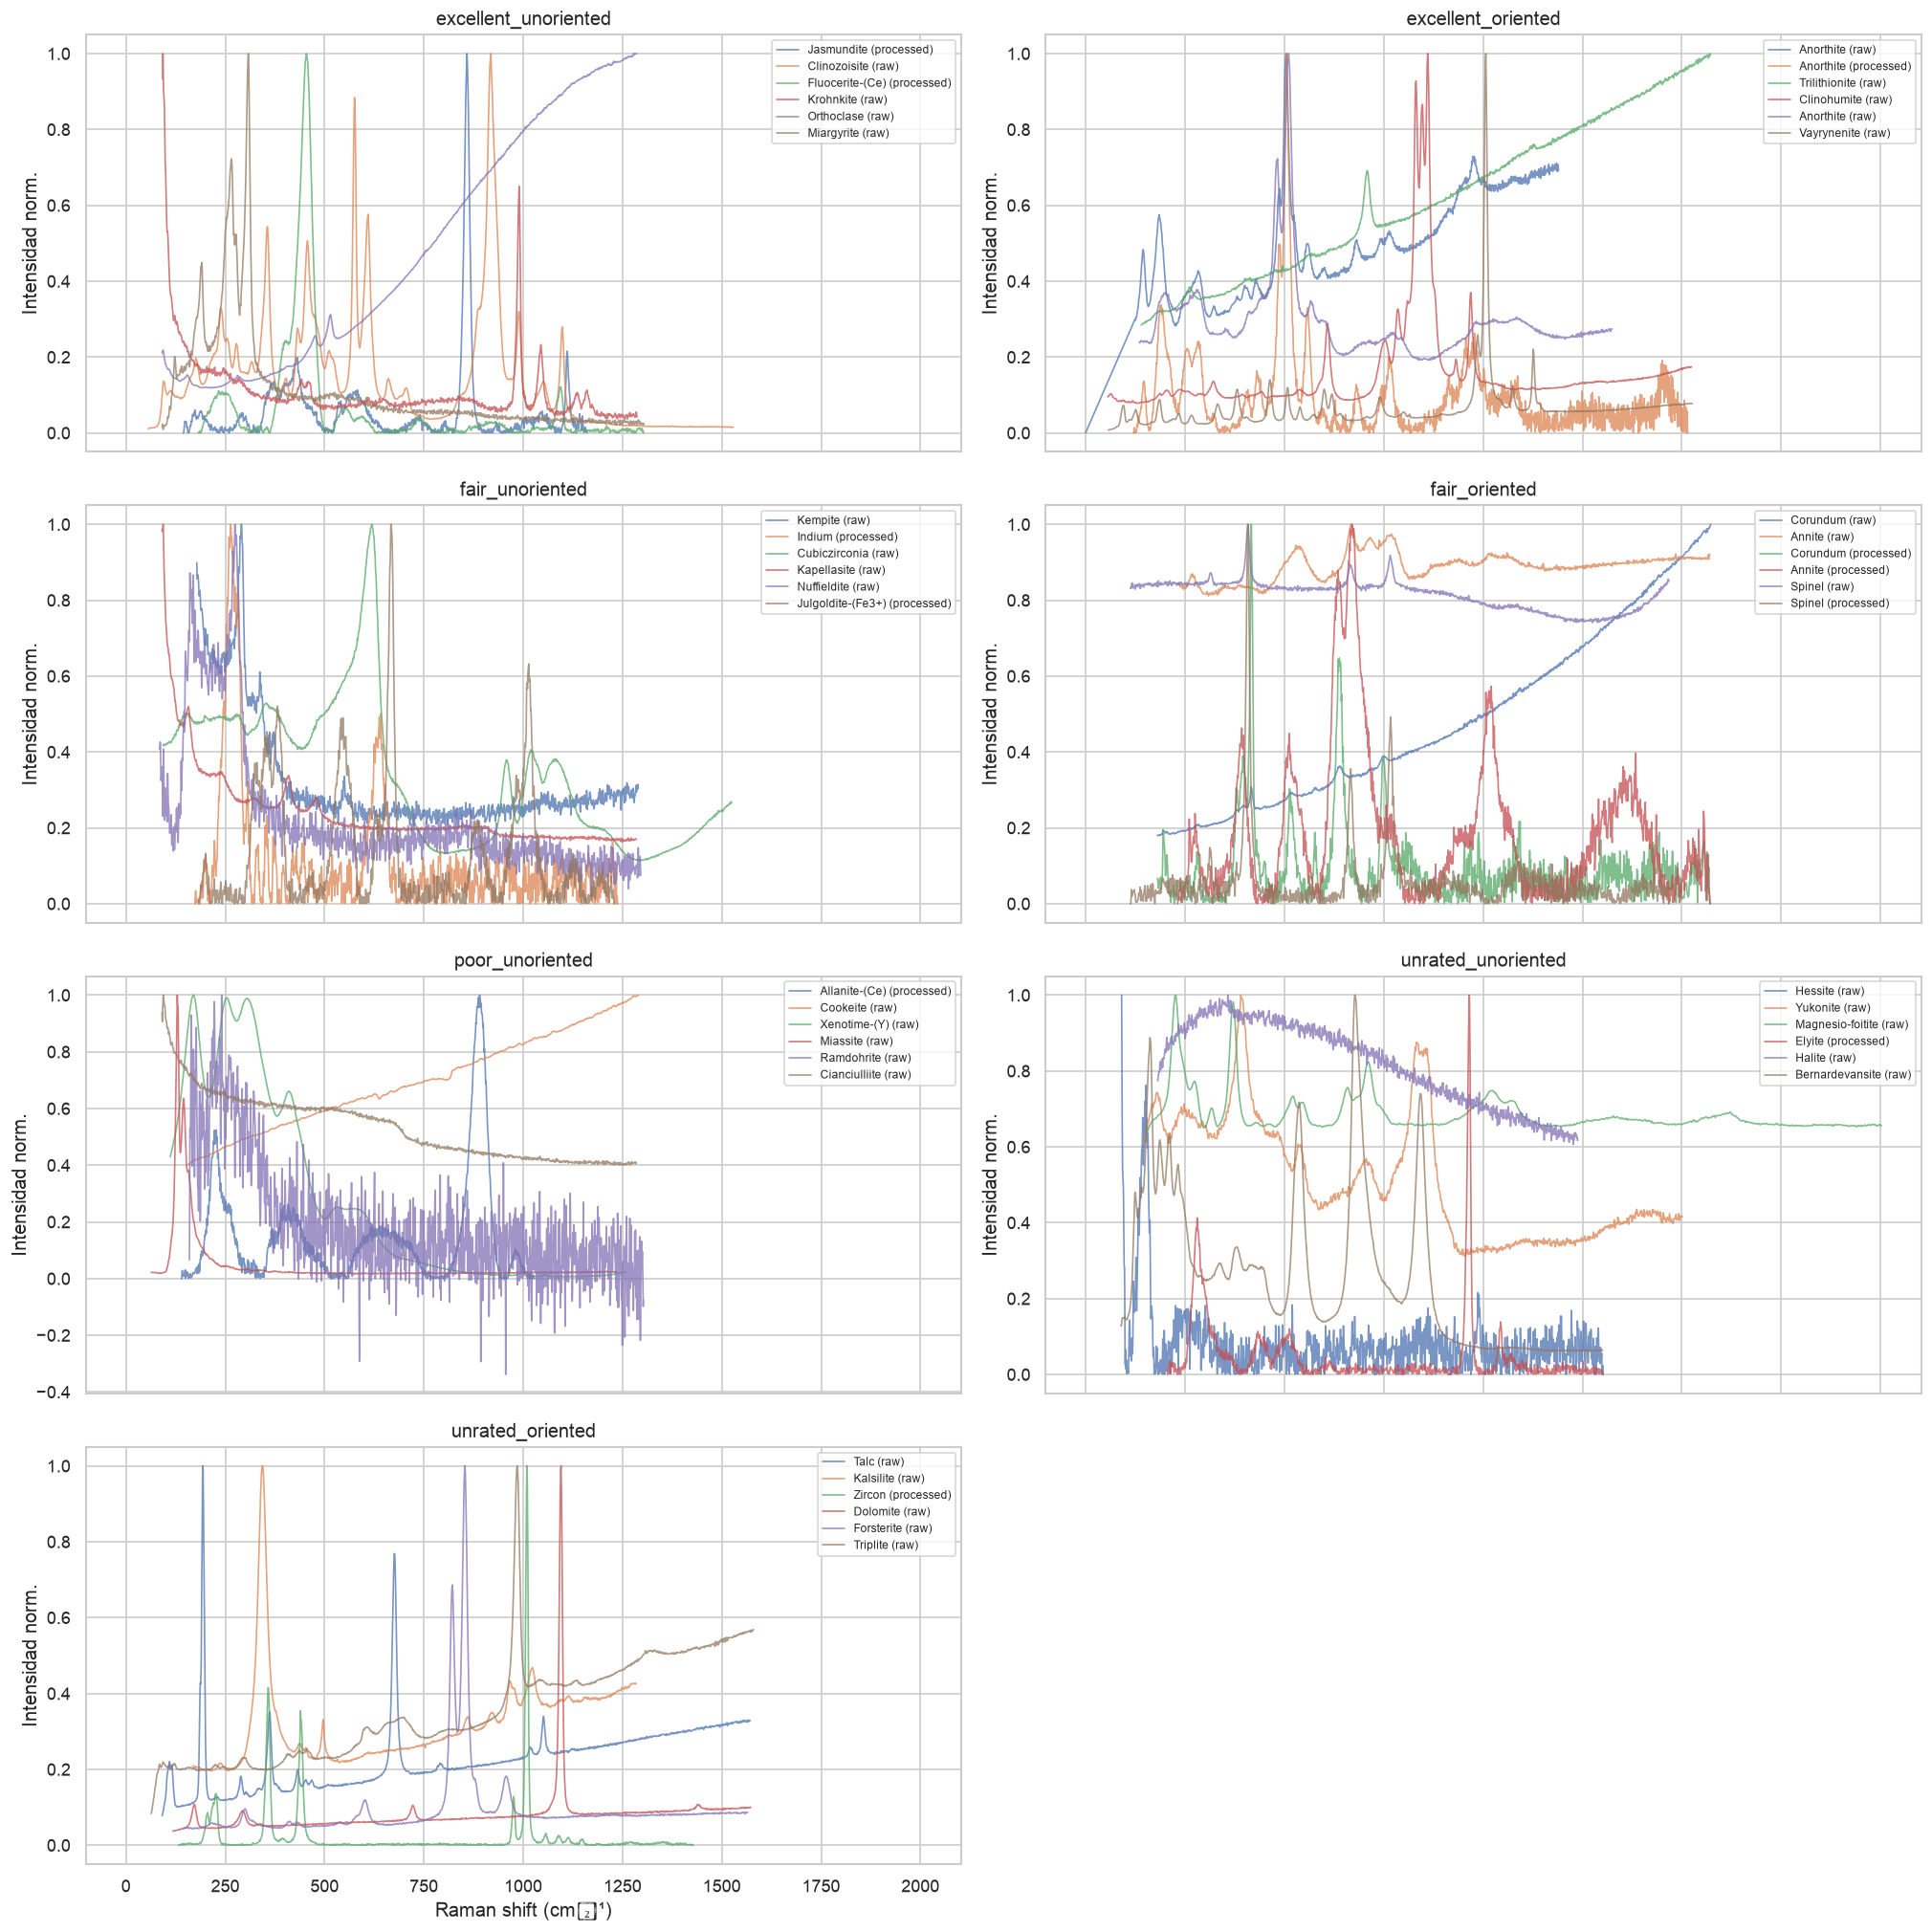

In [12]:
domains = archive_table.domain.tolist()
fig, axes = plt.subplots(4, 2, figsize=(17,17), sharex=True)
axes = axes.ravel()
for ax, domain in zip(axes, domains):
    for _, x, y, label, kind in plot_reservoir[domain]:
        yn = y / max(np.max(np.abs(y)), 1e-12)
        ax.plot(x, yn, alpha=.75, lw=1, label=f"{label} ({kind})")
    ax.set_title(domain); ax.set_ylabel("Intensidad norm."); ax.legend(fontsize=7, loc="upper right")
axes[len(domains)].axis("off")
for ax in axes[-2:]: ax.set_xlabel("Raman shift (cm⁻¹)")
plt.tight_layout(); plt.show()


## 12. Perfil medio comparable y PCA (muestra estratificada)

Se usa el intervalo robusto común definido por el percentil 95 de los mínimos y el percentil 5 de los máximos. Luego se interpola una muestra estratificada sobre 512 puntos, se normaliza y se proyecta con PCA. Esta visualización explora efectos de dominio; **no demuestra separabilidad causal**.

Intervalo robusto común: 187.27–1236.35 cm⁻¹


/var/folders/7k/fp9wzk9j49b90hn85_mtsxvc0000gn/T/ipykernel_24941/2885772864.py:48: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/opt/anaconda3/envs/raman-cnn/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


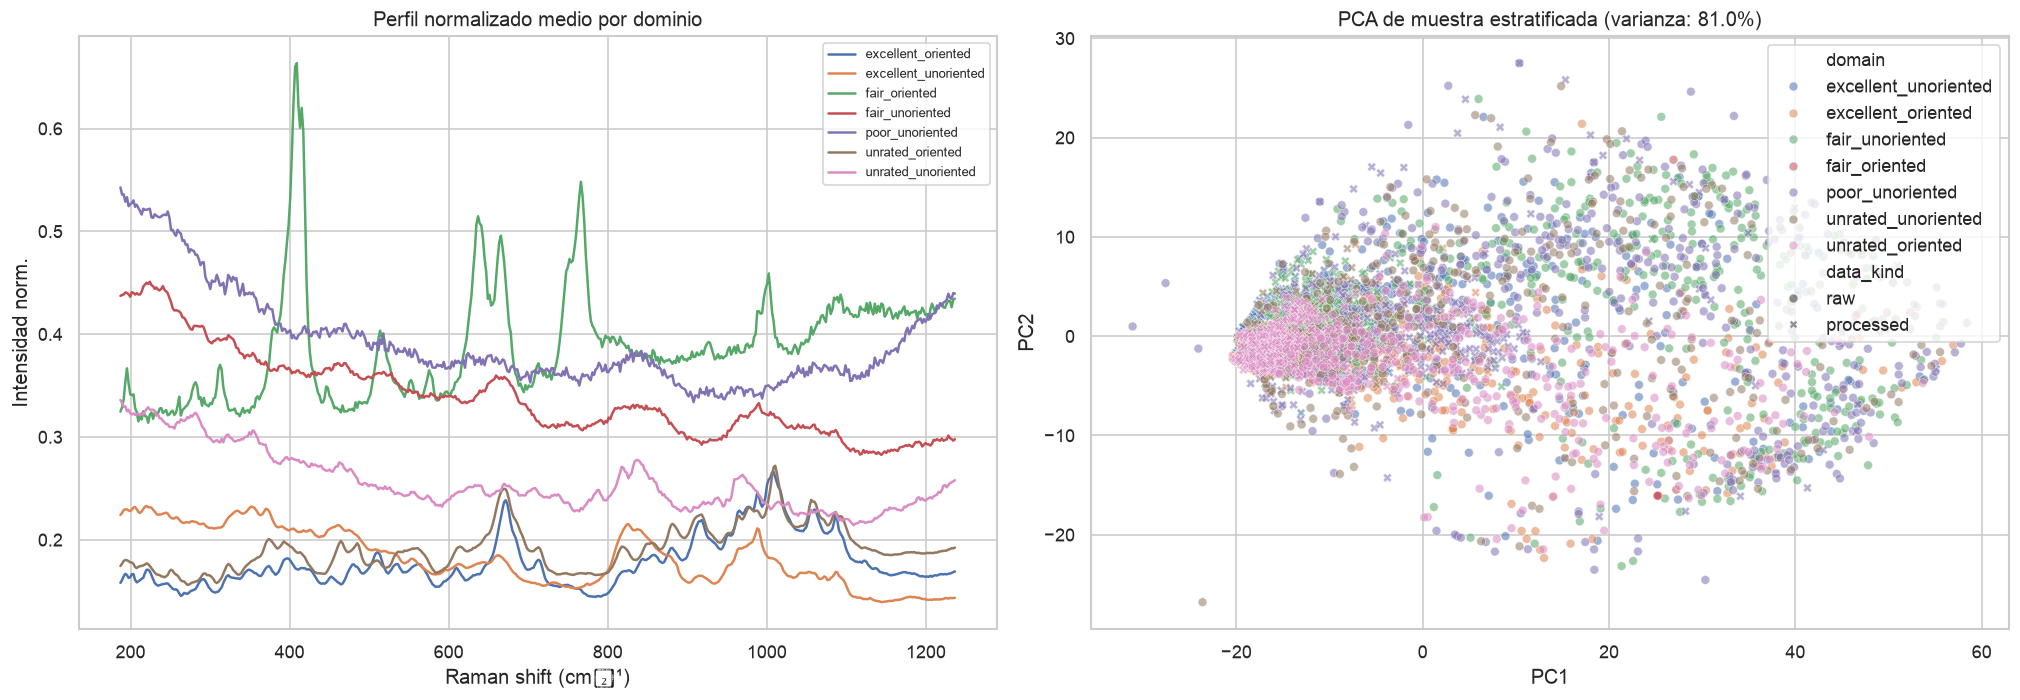


[SOLO PANTALLA] RRUFF_7_ZIPS_EDA_RESULTS/pca_sample_coordinates.csv | dimensiones: (4164, 30)


,spectrum_id,domain,quality,orientation,member,filename,label,source_id,source_id_status,source_id_filename,source_id_header,laser_nm,data_kind,polarization,angle_deg,accepted_parse,rejection_reason,sha256,bytes,n_points,min_shift,max_shift,span_shift,median_step,min_intensity,max_intensity,intensity_range,negative_fraction,PC1,PC2
0,S0006975,excellent_unoriented,excellent,unoriented,Opal__R110107__Raman__532______Raman_Data_RAW_...,Opal__R110107__Raman__532______Raman_Data_RAW_...,Opal,R110107,filename_header_agree,R110107,R110107,532.0,raw,unspecified,NaN,True,None,d993e193485c1727f6b6e5b509e8a437c86d8dee775b9b...,47679,2364,163.77390,1303.016,1139.24210,0.4821,12.177060,259.3895,247.212440,0.00000,6.523731,22.080399
1,S0011310,excellent_unoriented,excellent,unoriented,Skachaite__R250116__Raman__633______Raman_Data...,Skachaite__R250116__Raman__633______Raman_Data...,Skachaite,R250116,filename_header_agree,R250116,R250116,633.0,processed,unspecified,NaN,True,None,e4849abb2c5d442d222a4a6dec12849792284cf9eed78f...,140242,4099,49.21350,4000.642,3951.42850,0.9640,0.000000,1017.1410,1017.141000,0.00000,-19.364897,-2.449516
2,S0009065,excellent_unoriented,excellent,unoriented,Strengite__R040177__Raman__532______Raman_Data...,Strengite__R040177__Raman__532______Raman_Data...,Strengite,R040177,filename_header_agree,R040177,R040177,532.0,raw,unspecified,NaN,True,None,3f1085308974f12f012893c8d4a58733187b812ca0b88c...,49334,2432,132.78770,1304.814,1172.02630,0.4821,831.558100,71910.2700,71078.711900,0.00000,-15.238916,-1.702085
3,S0009238,excellent_unoriented,excellent,unoriented,Talmessite__R060830__Raman__532______Raman_Dat...,Talmessite__R060830__Raman__532______Raman_Dat...,Talmessite,R060830,filename_header_agree,R060830,R060830,532.0,processed,unspecified,NaN,True,None,3b99cfae257a9ab14f136d68ffea7ce234b97b04a9ba95...,49937,2461,111.39860,1297.405,1186.00640,0.4821,0.000000,68946.8100,68946.810000,0.00000,-17.919762,-1.503549
4,S0007341,excellent_unoriented,excellent,unoriented,Pharmacolite__R050537__Raman__780______Raman_D...,Pharmacolite__R050537__Raman__780______Raman_D...,Pharmacolite,R050537,filename_header_agree,R050537,R050537,780.0,processed,unspecified,NaN,True,None,b39ccb2e065bd530e357106288b990492ec78f088c653b...,50277,2470,95.75177,1286.098,1190.34623,0.4821,-0.361649,4045.6670,4046.028649,0.00081,-14.858255,-1.217068
5,S0008614,excellent_unoriented,excellent,unoriented,Shuiskite-(Mg)__R070109__Raman__532______Raman...,Shuiskite-(Mg)__R070109__Raman__532______Raman...,Shuiskite-(Mg),R070109,filename_header_agree,R070109,R070109,532.0,raw,unspecified,NaN,True,None,3796ca29462613efad9e32fa09cfc8df0387f16546158b...,50010,2466,124.62970,1313.046,1188.41630,0.4821,752.520900,6339.8190,5587.298100,0.00000,15.488766,9.824074
6,S0004197,excellent_unoriented,excellent,unoriented,Gmelinite-Na__R110191__Raman__532______Raman_D...,Gmelinite-Na__R110191__Raman__532______Raman_D...,Gmelinite-Na,R110191,filename_header_agree,R110191,R110191,532.0,raw,unspecified,NaN,True,None,5421a453ec82d3041563ac795b3541636a3d55142c48ca...,76176,2517,90.01007,1303.016,1213.00593,0.4821,0.000000,209.9228,209.922800,0.00000,34.850437,-3.650146
7,S0006096,excellent_unoriented,excellent,unoriented,Marokite__R070275__Raman__785______Raman_Data_...,Marokite__R070275__Raman__785______Raman_Data_...,Marokite,R070275,filename_header_agree,R070275,R070275,785.0,processed,unspecified,NaN,True,None,324f156d24af3e98eacf1e8b57eae83fbf13a60fb26fc9...,47279,2328,121.01940,1242.905,1121.88560,0.4821,0.000000,15231.0300,15231.030000,0.00000,-15.399163,2.312537
8,S0002644,excellent_unoriented,excellent,unoriented,Curite__R130657__Raman__780______Raman_Data_Pr...,Curite__R130657__Raman__780______Raman_Data_Pr...,Curite,R130657,filename_header_agree,R130657,R130657,780.0,processed,unspecified,NaN,True,None,701d7953a2dda46ed3ebbf0662dbc95de7846042912066...,48186,2367,141.57940,1282.268,1140.68860,0.4821,0.000000,7165.1310,7165.131000,0.00000,-11.044135,3.832315
9,S0006


[SOLO PANTALLA] RRUFF_7_ZIPS_EDA_RESULTS/mean_normalized_profiles.csv | dimensiones: (512, 8)


,raman_shift,excellent_oriented,excellent_unoriented,fair_oriented,fair_unoriented,poor_unoriented,unrated_oriented,unrated_unoriented
0,187.266907,0.158126,0.224251,0.324625,0.437253,0.542690,0.174541,0.335965
1,189.319901,0.160842,0.226197,0.328891,0.438167,0.535822,0.176766,0.332999
2,191.372910,0.164519,0.229018,0.336794,0.438572,0.535957,0.179459,0.329562
3,193.425919,0.166950,0.229609,0.353426,0.440584,0.528839,0.180293,0.329921
4,195.478928,0.165643,0.229549,0.366757,0.440060,0.533261,0.180069,0.325003
5,197.531937,0.162926,0.228457,0.352176,0.438823,0.524493,0.179229,0.326513
6,199.584930,0.163574,0.227925,0.341420,0.436485,0.526321,0.178002,0.323108
7,201.637939,0.166584,0.229406,0.340788,0.440810,0.527603,0.177861,0.321968
8,203.690948,0.166603,0.231404,0.341390,0.440133,0.530117,0.176611,0.323023
9,205.743958,0.160847,0.231834,0.328182,0.438516,0.523832,0.173352,0.321467


In [13]:
valid = ok.dropna(subset=["min_shift","max_shift"])
grid_min = float(valid.min_shift.quantile(.95))
grid_max = float(valid.max_shift.quantile(.05))
if grid_min >= grid_max:
    raise RuntimeError("No existe un intervalo robusto común; revise cobertura por dominio.")
grid = np.linspace(grid_min, grid_max, N_GRID_POINTS, dtype=np.float32)
print(f"Intervalo robusto común: {grid_min:.2f}–{grid_max:.2f} cm⁻¹")

# Selección estratificada de IDs; los bytes se vuelven a leer únicamente para esta muestra.
eligible = valid[(valid.min_shift <= grid_min) & (valid.max_shift >= grid_max)].copy()
per_domain = max(1, PCA_SAMPLE_SIZE // eligible.domain.nunique())
# Barajar primero y limitar después conserva `domain` como columna en todas
# las versiones recientes de pandas (sin depender de groupby.apply).
sample_meta = (eligible.sample(frac=1, random_state=RANDOM_SEED)
               .groupby("domain", group_keys=False, sort=False)
               .head(per_domain)
               .copy())
target_ids = set(sample_meta.spectrum_id)
vectors, vector_rows = [], []
# Conservar todas las columnas, incluidas las claves. Al usar set_index + loc,
# pandas elimina `domain` y `member` de la Series recuperada.
record_lookup = {(row["domain"], row["member"]): row
                 for row in sample_meta.to_dict(orient="records")}

for zip_name, zip_path in archives.items():
    domain = Path(zip_name).stem
    wanted = set(sample_meta.loc[sample_meta.domain == domain, "member"])
    with zipfile.ZipFile(zip_path) as zf:
        for member in wanted:
            result, _, _ = parse_spectrum_bytes(zf.read(member))
            if result is None: continue
            x, y = result; v = np.interp(grid, x, y).astype(np.float32)
            v /= max(float(np.max(np.abs(v))), 1e-7)
            vectors.append(v); vector_rows.append(record_lookup[(domain, member)].copy())

X_plot = np.stack(vectors)
pca_meta = pd.DataFrame(vector_rows).reset_index(drop=True)
pca = PCA(n_components=2, random_state=RANDOM_SEED)
Z = pca.fit_transform(StandardScaler().fit_transform(X_plot))
pca_meta["PC1"], pca_meta["PC2"] = Z[:,0], Z[:,1]

fig, axes = plt.subplots(1, 2, figsize=(17,6))
for domain, idx in pca_meta.groupby("domain").groups.items():
    axes[0].plot(grid, X_plot[list(idx)].mean(axis=0), label=domain, lw=1.5)
axes[0].set(title="Perfil normalizado medio por dominio", xlabel="Raman shift (cm⁻¹)", ylabel="Intensidad norm."); axes[0].legend(fontsize=8)
sns.scatterplot(data=pca_meta, x="PC1", y="PC2", hue="domain", style="data_kind", alpha=.55, s=28, ax=axes[1])
axes[1].set_title(f"PCA de muestra estratificada (varianza: {pca.explained_variance_ratio_.sum():.1%})")
plt.tight_layout(); plt.show()

pca_meta.to_csv(OUTPUT_DIR / "pca_sample_coordinates.csv", index=False)
pd.DataFrame({"raman_shift":grid, **{d:X_plot[list(idx)].mean(axis=0) for d,idx in pca_meta.groupby("domain").groups.items()}}).to_csv(OUTPUT_DIR / "mean_normalized_profiles.csv", index=False)


## 13. Relaciones de multicolinealidad entre los siete dominios

Para comparar directamente los siete ZIP, se calcula la **correlación de Pearson entre sus perfiles Raman medios normalizados** sobre la misma rejilla de 512 puntos. El mapa de calor está ordenado mediante agrupamiento jerárquico: valores cercanos a 1 indican perfiles medios muy parecidos y, por tanto, posible redundancia o multicolinealidad de dominio.

Esta es una medida exploratoria de similitud espectral, no una prueba causal. Puede reflejar tanto condiciones de adquisición (calidad, orientación, RAW/Processed) como diferencias en la composición de minerales de cada ZIP. No se calcula VIF porque los dominios son categorías, no siete predictores continuos simultáneos.

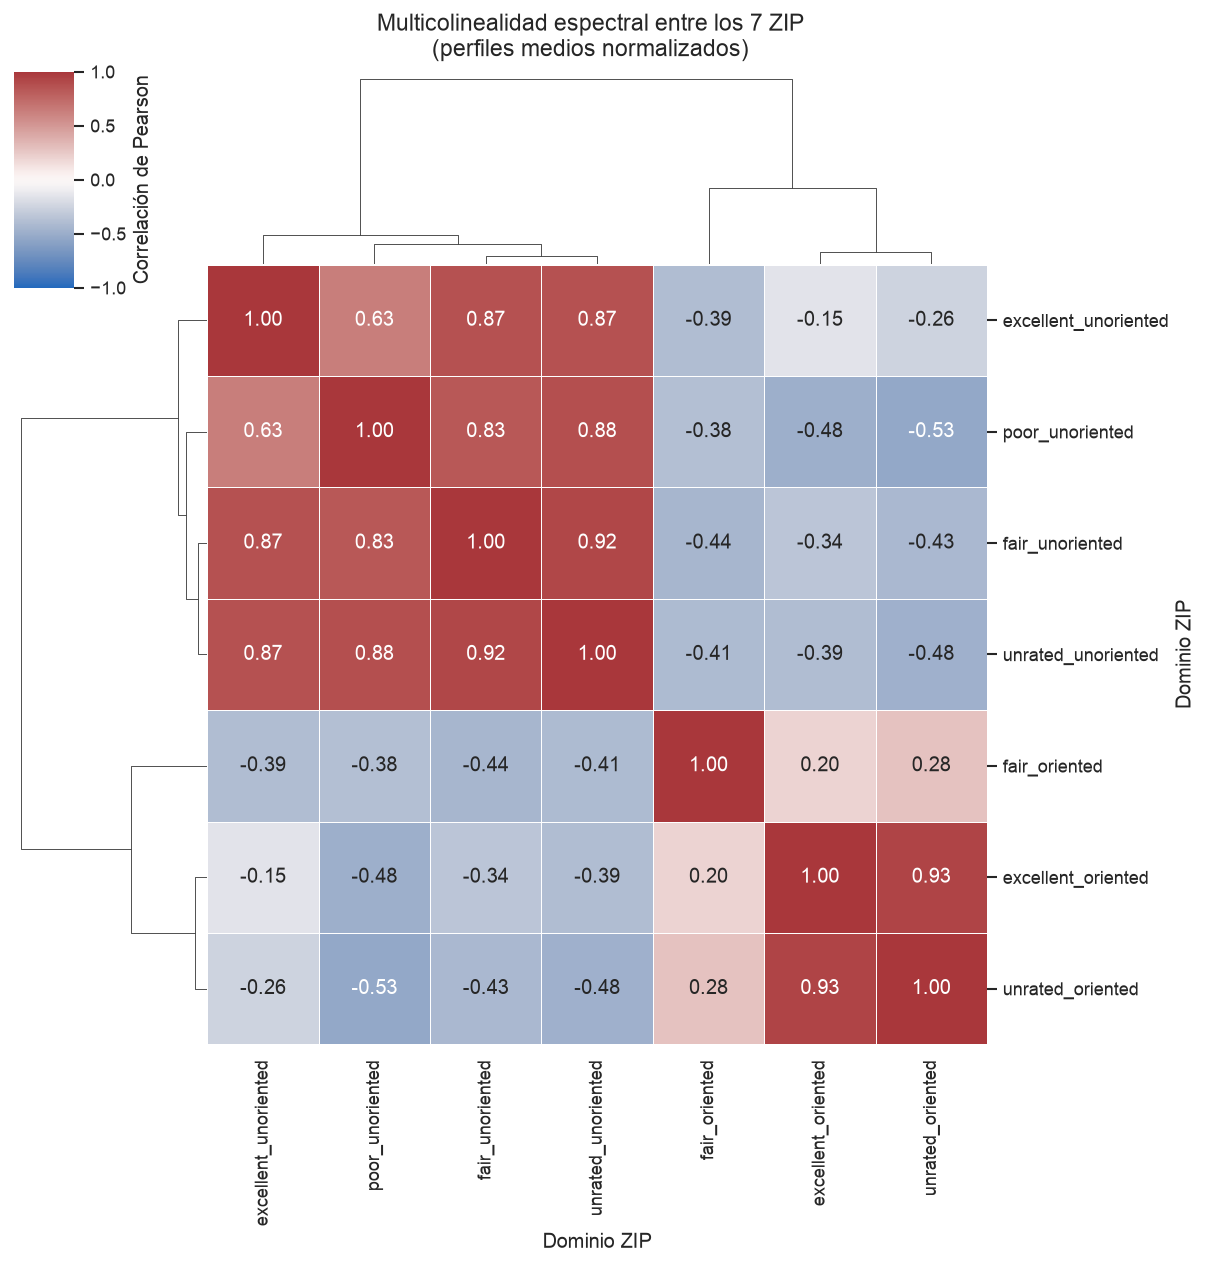

Relaciones espectrales más fuertes entre dominios:


,domain_a,domain_b,pearson_r
0,excellent_oriented,unrated_oriented,0.931
1,fair_unoriented,unrated_unoriented,0.919
2,poor_unoriented,unrated_unoriented,0.879
3,excellent_unoriented,fair_unoriented,0.872
4,excellent_unoriented,unrated_unoriented,0.869
5,fair_unoriented,poor_unoriented,0.835
6,excellent_unoriented,poor_unoriented,0.635
7,fair_oriented,unrated_oriented,0.283
8,excellent_oriented,fair_oriented,0.199
9,excellent_oriented,excellent_unoriented,-0.152


Nota: una correlación alta describe similitud entre perfiles medios; no implica fuga de datos por sí sola.


In [14]:
# Matriz dominio × Raman shift construida a partir de los perfiles medios ya calculados.
domain_profiles = pd.DataFrame({
    domain: X_plot[list(indices)].mean(axis=0)
    for domain, indices in pca_meta.groupby("domain").groups.items()
}, index=grid)
domain_profiles.index.name = "raman_shift_cm-1"
domain_correlation = domain_profiles.corr(method="pearson")

# Clustermap: el dendrograma agrupa los dominios con perfiles medios más similares.
cluster = sns.clustermap(
    domain_correlation,
    cmap="vlag", vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f", linewidths=.6,
    figsize=(10, 10),
    cbar_kws={"label": "Correlación de Pearson"},
)
cluster.ax_heatmap.set_xlabel("Dominio ZIP")
cluster.ax_heatmap.set_ylabel("Dominio ZIP")
cluster.fig.suptitle("Multicolinealidad espectral entre los 7 ZIP\n(perfiles medios normalizados)", y=1.03, fontsize=14)
plt.show()

# Ranking de relaciones fuera de la diagonal para facilitar la interpretación.
upper = domain_correlation.where(np.triu(np.ones(domain_correlation.shape, dtype=bool), k=1))
pairs = (upper.stack().rename("pearson_r").reset_index()
         .rename(columns={"level_0": "domain_a", "level_1": "domain_b"})
         .sort_values("pearson_r", ascending=False, ignore_index=True))
print("Relaciones espectrales más fuertes entre dominios:")
display(pairs.head(10).style.format({"pearson_r": "{:.3f}"}).background_gradient(subset=["pearson_r"], cmap="Reds"))
print("Nota: una correlación alta describe similitud entre perfiles medios; no implica fuga de datos por sí sola.")


## 14. Tabla de síntesis y conclusiones automáticas

La siguiente celda resume hallazgos descriptivos y genera advertencias metodológicas. Las conclusiones deben interpretarse junto con los gráficos, no como reglas automáticas de exclusión.

In [15]:
final_summary = parse_summary.merge(summary, on="domain", how="left")
final_summary["spectra_per_source"] = final_summary["spectra"] / final_summary["sources"].replace(0,np.nan)
final_summary["class_coverage_pct"] = final_summary["minerals_y"] / ok.label.nunique()
display(final_summary)
final_summary.to_csv(OUTPUT_DIR / "EDA_DOMAIN_SUMMARY.csv", index=False)

findings = {
    "total_text_files": int(len(manifest)),
    "successfully_parsed": int(manifest.accepted_parse.sum()),
    "unique_minerals_parsed": int(ok.label.nunique()),
    "unique_resolved_sources": int(ok.source_id.nunique()),
    "classes_with_at_least_3_sources": int((source_per_class >= 3).sum()),
    "classes_with_fewer_than_3_sources": int((source_per_class < 3).sum()),
    "exact_duplicate_groups": int(len(dup_summary)),
    "source_label_conflicts": int(len(conflicts)),
    "robust_common_interval_cm-1": [grid_min, grid_max],
}
(OUTPUT_DIR / "EDA_KEY_FINDINGS.json").write_text(json.dumps(findings, indent=2), encoding="utf-8")

print("HALLAZGOS CLAVE")
for k,v in findings.items(): print(f"• {k}: {v}")
print("\nIMPLICACIONES")
print("• Dividir por source_id, nunca aleatoriamente por archivo, para evitar fuga entre dominios.")
print("• Informar métricas por dominio además de la métrica global.")
print("• Tratar RAW/Processed y orientación como variables de dominio explícitas.")
print("• Documentar clases con pocas fuentes antes de decidir validación cruzada agrupada.")
print("• Resolver o excluir conflictos de fuente-etiqueta antes del modelado.")


,domain,files,parsed,resolved_sources,unique_sources,minerals_x,parse_rate,source_resolution_rate,spectra,minerals_y,sources,spectra_per_source,class_coverage_pct
0,excellent_oriented,7668,7668,7536,442,216,1.0,0.982786,7668,216,442,17.348416,0.086090
1,excellent_unoriented,11415,11415,10332,2882,1958,1.0,0.905125,11415,1958,2882,3.960791,0.780391
2,fair_oriented,25,25,17,4,4,1.0,0.680000,25,4,4,6.250000,0.001594
3,fair_unoriented,2951,2951,2694,1011,889,1.0,0.912911,2951,889,1011,2.918892,0.354324
4,poor_unoriented,1639,1639,1500,603,533,1.0,0.915192,1639,533,603,2.718076,0.212435
5,unrated_oriented,3778,3778,3700,481,217,1.0,0.979354,3778,217,481,7.854470,0.086489
6,unrated_unoriented,639,639,434,197,271,1.0,0.679186,639,271,197,3.243655,0.108011



[SOLO PANTALLA] RRUFF_7_ZIPS_EDA_RESULTS/EDA_DOMAIN_SUMMARY.csv | dimensiones: (7, 13)


,domain,files,parsed,resolved_sources,unique_sources,minerals_x,parse_rate,source_resolution_rate,spectra,minerals_y,sources,spectra_per_source,class_coverage_pct
0,excellent_oriented,7668,7668,7536,442,216,1.0,0.982786,7668,216,442,17.348416,0.086090
1,excellent_unoriented,11415,11415,10332,2882,1958,1.0,0.905125,11415,1958,2882,3.960791,0.780391
2,fair_oriented,25,25,17,4,4,1.0,0.680000,25,4,4,6.250000,0.001594
3,fair_unoriented,2951,2951,2694,1011,889,1.0,0.912911,2951,889,1011,2.918892,0.354324
4,poor_unoriented,1639,1639,1500,603,533,1.0,0.915192,1639,533,603,2.718076,0.212435
5,unrated_oriented,3778,3778,3700,481,217,1.0,0.979354,3778,217,481,7.854470,0.086489
6,unrated_unoriented,639,639,434,197,271,1.0,0.679186,639,271,197,3.243655,0.108011


[SOLO PANTALLA] EDA_KEY_FINDINGS.json:
{
  "total_text_files": 28115,
  "successfully_parsed": 28115,
  "unique_minerals_parsed": 2509,
  "unique_resolved_sources": 3677,
  "classes_with_at_least_3_sources": 259,
  "classes_with_fewer_than_3_sources": 2070,
  "exact_duplicate_groups": 16,
  "source_label_conflicts": 2,
  "robust_common_interval_cm-1": [
    187.2669,
    1236.353
  ]
}
HALLAZGOS CLAVE
• total_text_files: 28115
• successfully_parsed: 28115
• unique_minerals_parsed: 2509
• unique_resolved_sources: 3677
• classes_with_at_least_3_sources: 259
• classes_with_fewer_than_3_sources: 2070
• exact_duplicate_groups: 16
• source_label_conflicts: 2
• robust_common_interval_cm-1: [187.2669, 1236.353]

IMPLICACIONES
• Dividir por source_id, nunca aleatoriamente por archivo, para evitar fuga entre dominios.
• Informar métricas por dominio además de la métrica global.
• Tratar RAW/Processed y orientación como variables de dominio explícitas.
• Documentar clases con pocas fuentes antes 